# Trees & Cluster Trees - Embedding Visualisation

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
import numpy as np

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)

## Exp 1: Numbers Tree (ordered)

In [2]:
EMB_DIR     = Path("../embeddings/numbers/tree_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/tree_numbers/bin_tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

### PCA 2D

  [] Warning: token '15' has only 4 occurrences in [0:50] (requested 100)
  [] Warning: token '13' has only 8 occurrences in [0:50] (requested 100)
  [] Warning: token '12' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '14' has only 12 occurrences in [0:50] (requested 100)
  [] Warning: token '15' has only 20 occurrences in [0:500] (requested 100)
  [] Warning: token '11' has only 12 occurrences in [0:500] (requested 100)
  [] Warning: token '13' has only 19 occurrences in [0:500] (requested 100)
  [] Warning: token '12' has only 24 occurrences in [0:500] (requested 100)
  [] Warning: token '14' has only 51 occurrences in [0:500] (requested 100)
  [] Warning: token '1' has only 3 occurrences in [0:500] (requested 100)
  [] Warning: token '2' has only 13 occurrences in [0:500] (requested 100)
  [] Warning: token '3' has only 7 occurrences in [0:500] (requested 100)
  [] Warning: token '4' has only 23 occurrences in [0:500] (requested 100)
  [] Warning: token '5' h

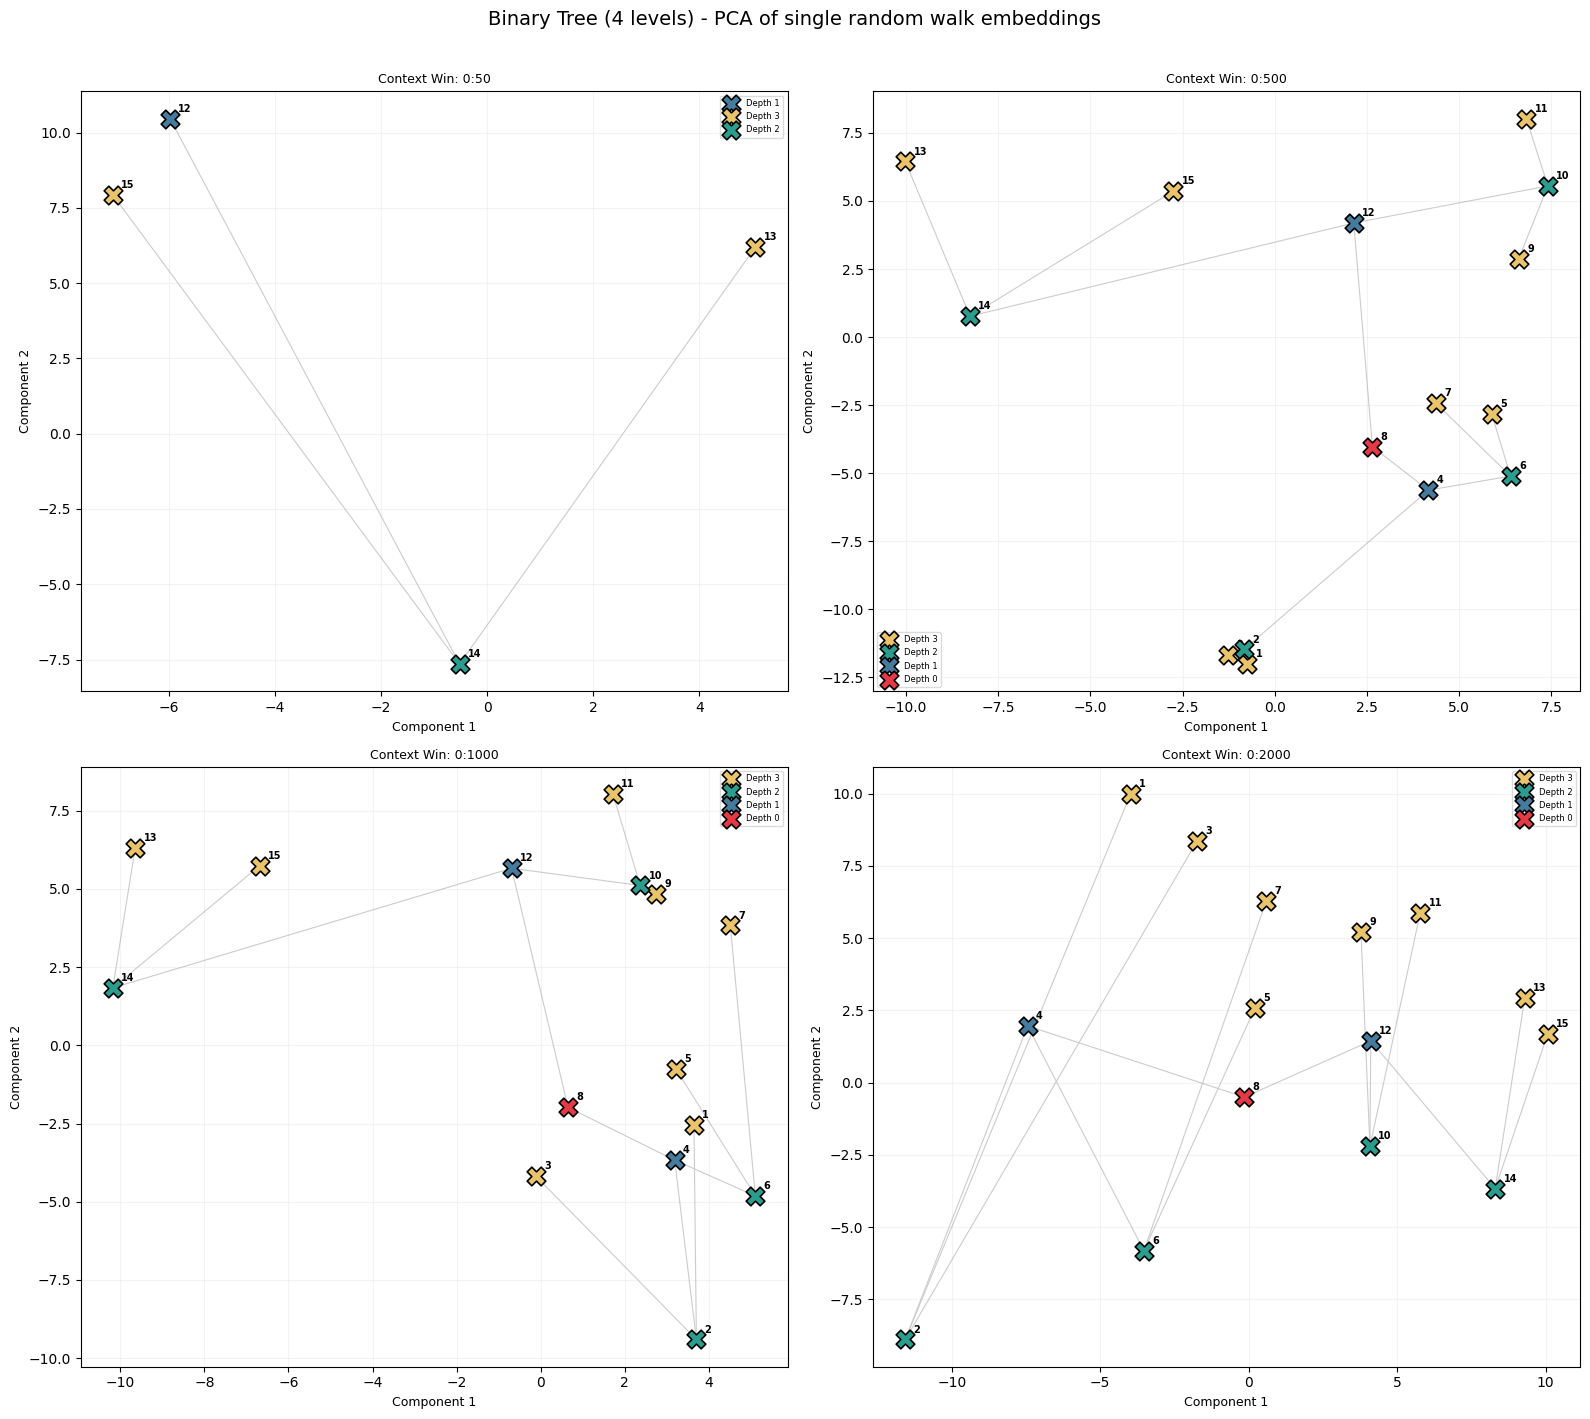

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=100, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=True)

fig.suptitle("Binary Tree (4 levels) - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### Dendrogram

In [16]:
# fig, axes = plt.subplots(2, 2, figsize=(18, 18))

# CTX_LENS = [100, 500, 1000, 2000]

# layer = 3 # quale livello dell'albero dendrogrammo

# toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
# ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]


# for ax, win in zip(axes.flat, CTX_LENS):
#     print(f"Processing context length: {win}")
#     pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer31.pt"
#     ids_np, emb_np = load_embeddings_pt(pt_path)

#     mask_layer_l = np.isin(ids_np, ids_layer_l)

#     emb_np = emb_np[mask_layer_l]
#     ids_np = ids_np[mask_layer_l]

#     filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)
#     hp_tree.plot_dendrogram_on_points(ax, filtered_ids, filtered_embs, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

# fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
#              fontsize=14, y=1.01)
# fig.tight_layout()
# plt.show()

### dendrogram on centroids (cleaner plot)

Processing context length: 100
  [] Warning: token '1' has only 7 occurrences in [0:100] (requested 10)
  [] Warning: token '3' has only 8 occurrences in [0:100] (requested 10)
  [] Warning: token '7' has only 6 occurrences in [0:100] (requested 10)
Processing context length: 500
Processing context length: 1000
Processing context length: 2000


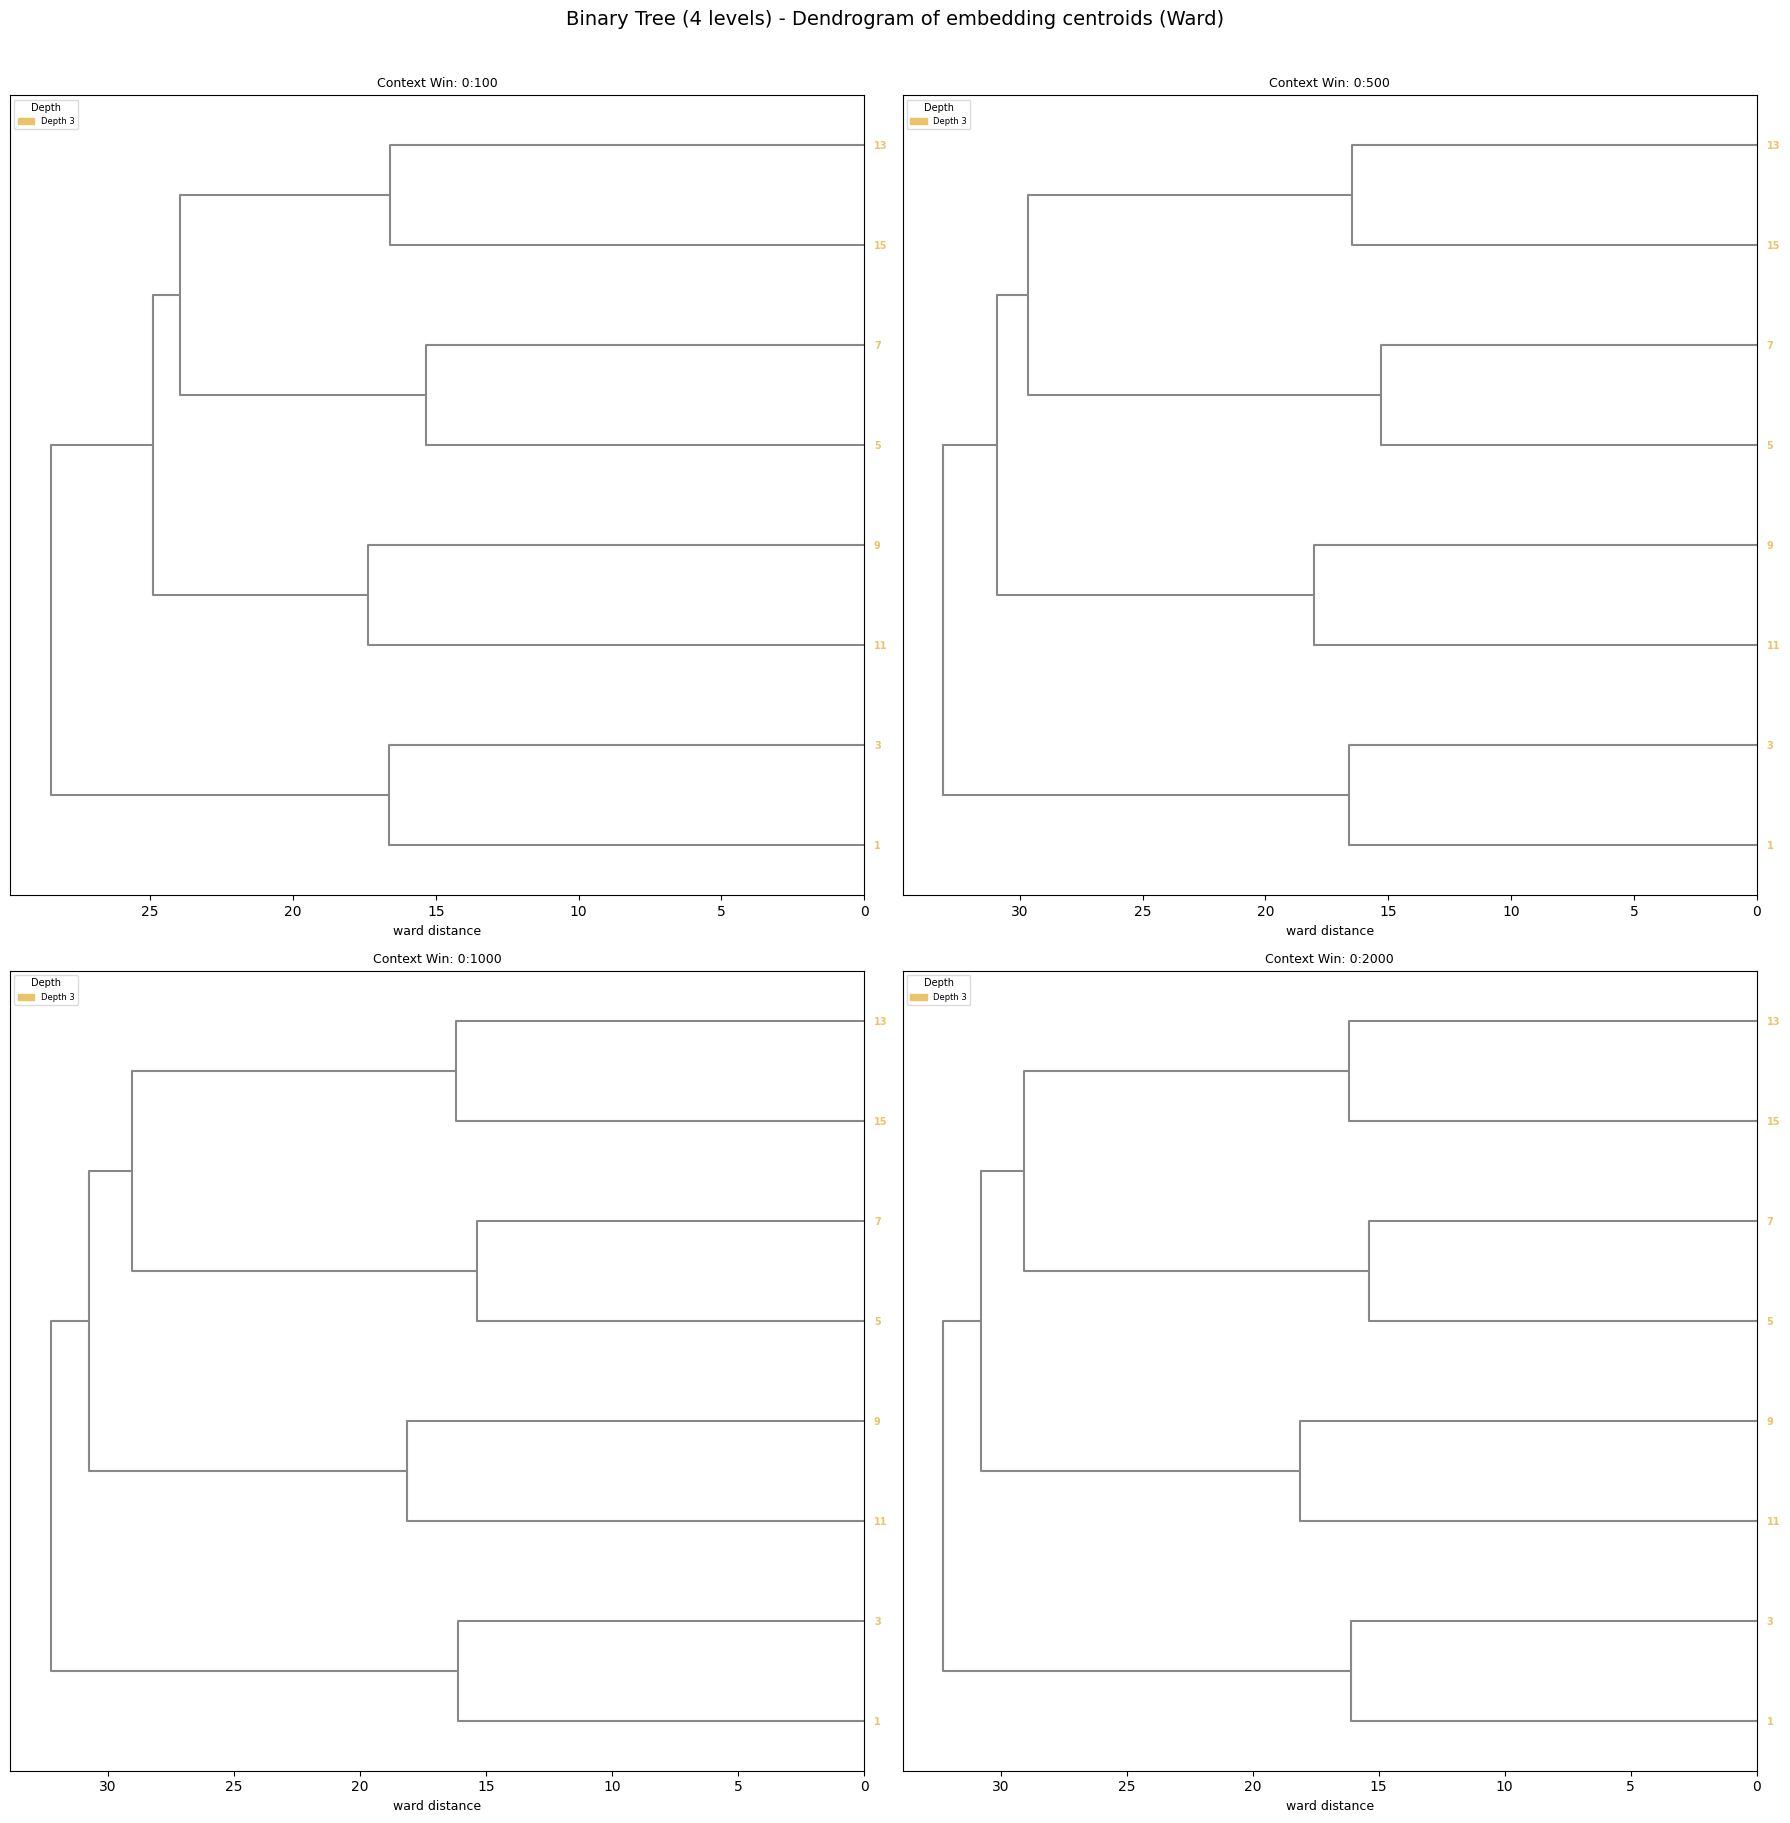

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 2: Numbers Tree (shuffled)

In [17]:
EMB_DIR     = Path("../embeddings/numbers/shuffled_tree_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_tree_numbers/bin_tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

### PCA 2D

  [] Warning: token '1' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '4' has only 8 occurrences in [0:50] (requested 100)
  [] Warning: token '7' has only 4 occurrences in [0:50] (requested 100)
  [] Warning: token '10' has only 12 occurrences in [0:50] (requested 100)
  [] Warning: token '15' has only 24 occurrences in [0:500] (requested 100)
  [] Warning: token '11' has only 23 occurrences in [0:500] (requested 100)
  [] Warning: token '13' has only 23 occurrences in [0:500] (requested 100)
  [] Warning: token '12' has only 3 occurrences in [0:500] (requested 100)
  [] Warning: token '14' has only 13 occurrences in [0:500] (requested 100)
  [] Warning: token '1' has only 24 occurrences in [0:500] (requested 100)
  [] Warning: token '2' has only 9 occurrences in [0:500] (requested 100)
  [] Warning: token '3' has only 14 occurrences in [0:500] (requested 100)
  [] Warning: token '4' has only 19 occurrences in [0:500] (requested 100)
  [] Warning: token '5' has 

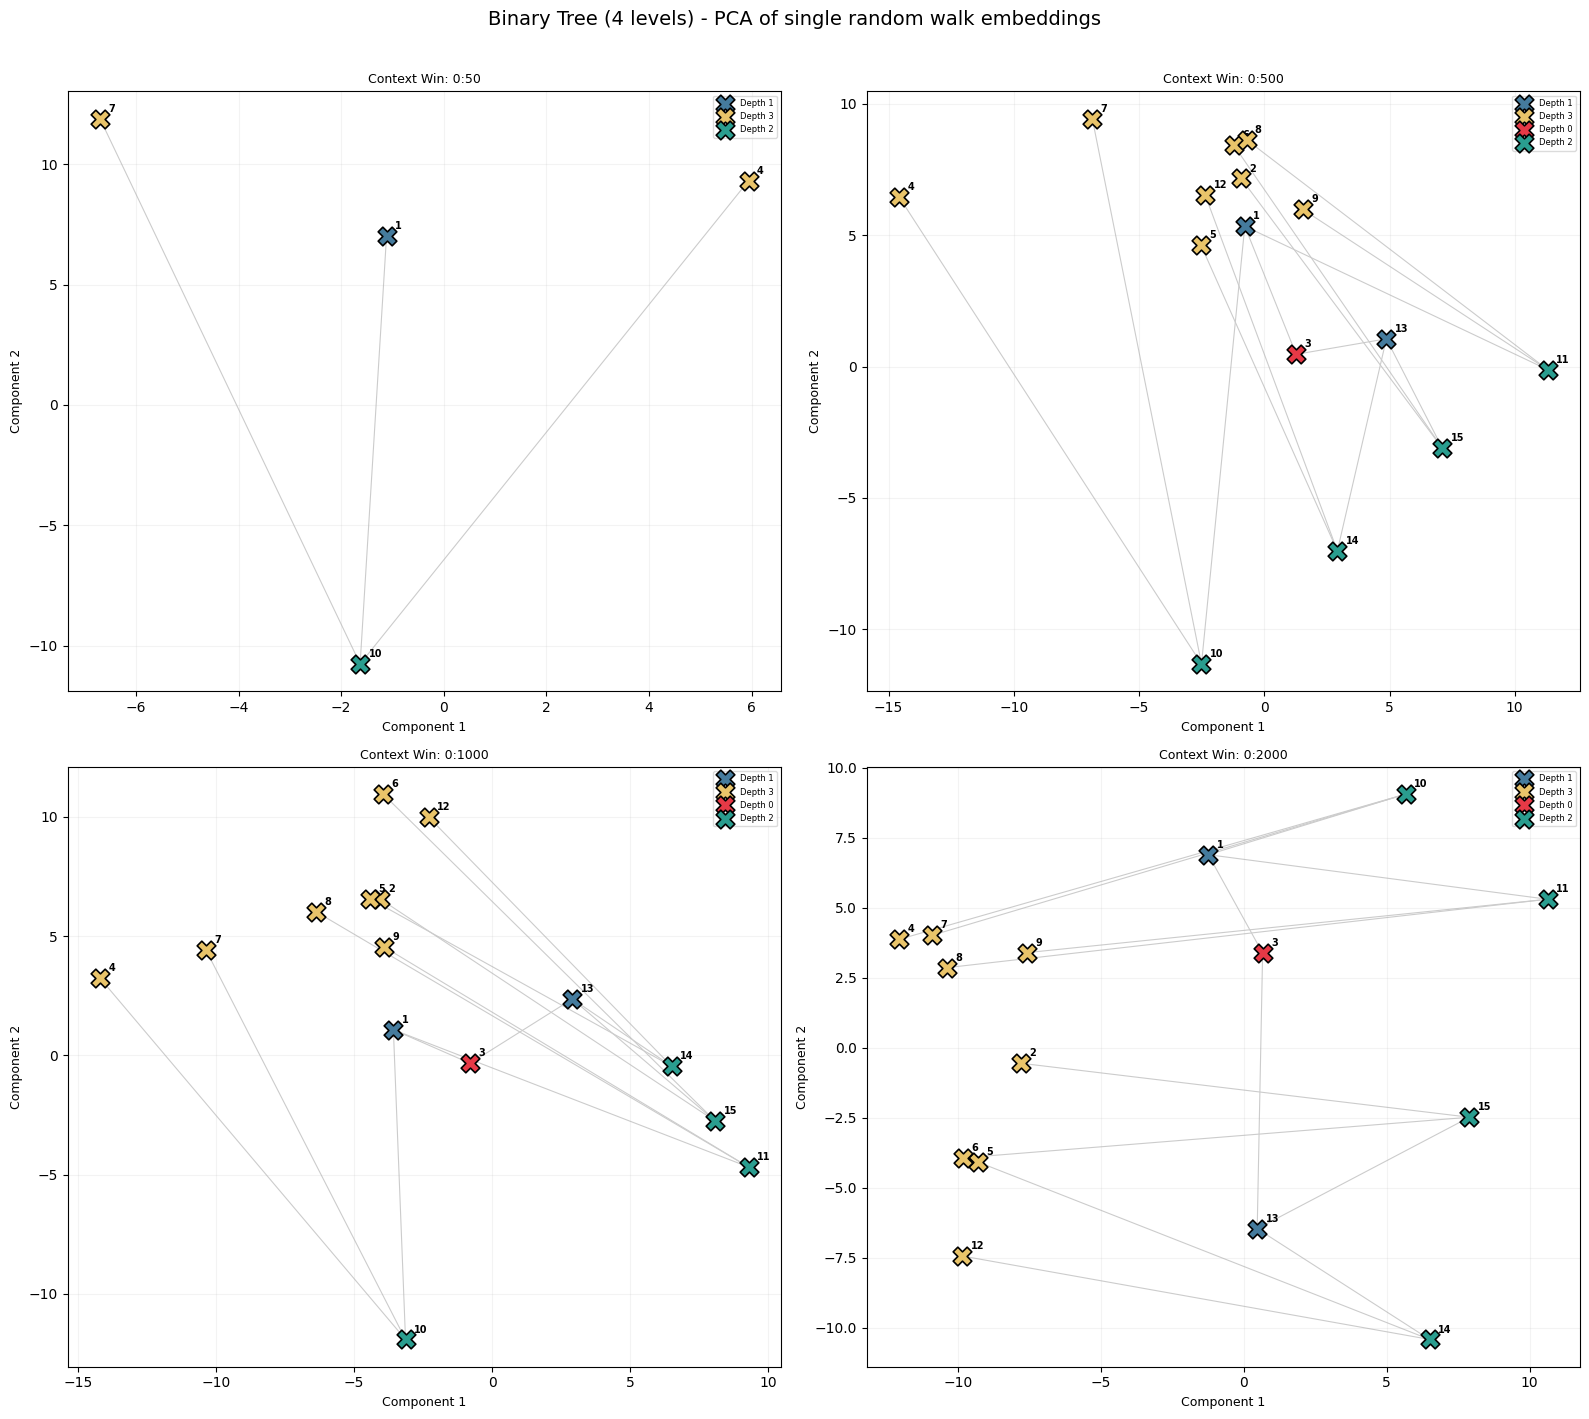

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_numbers_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=100, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=True)

fig.suptitle("Binary Tree (4 levels) - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### dendrogram on centroids (cleaner plot)

Processing context length: 50
  [] Warning: token '12' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '2' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '6' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '8' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
Processing context length: 500
Processing context length: 1000
Processing context length: 2000


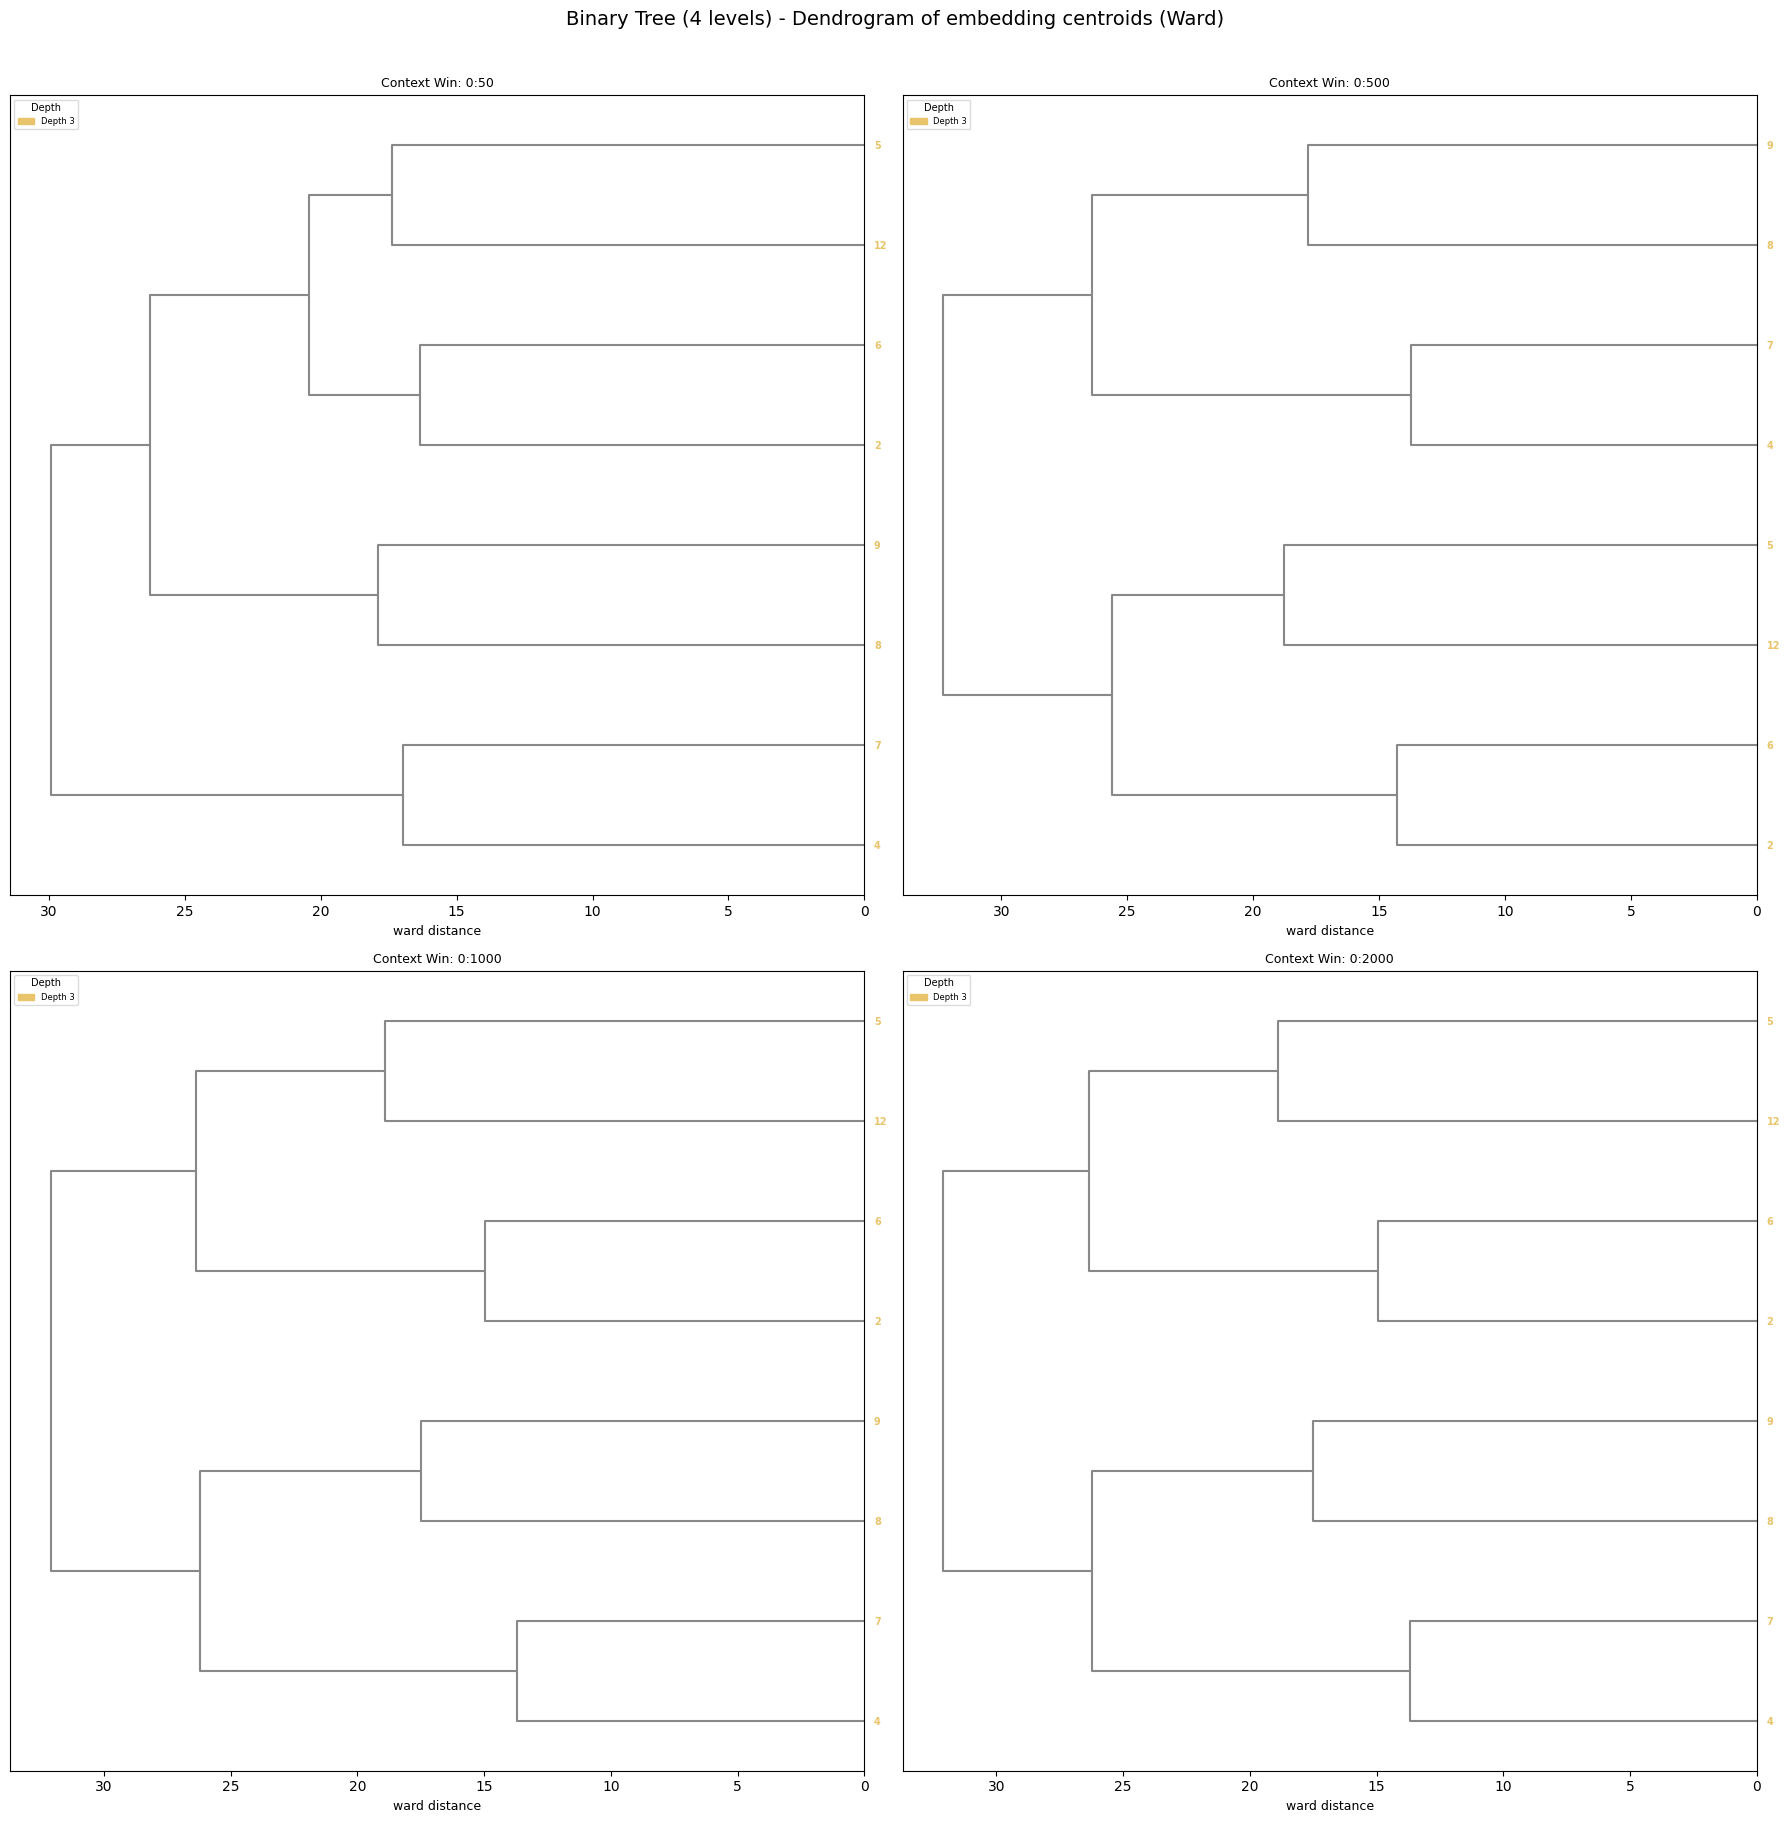

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_bin_tree_numbers_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 3: Numbers Grid (ordered)

In [2]:
EMB_DIR     = Path("../embeddings/numbers/grid_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/grid_numbers/grid_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

### PCA 2D

  [] Warning: token '15' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '12' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '1' has only 3 occurrences in [0:50] (requested 100)
  [] Warning: token '2' has only 3 occurrences in [0:50] (requested 100)
  [] Warning: token '3' has only 3 occurrences in [0:50] (requested 100)
  [] Warning: token '4' has only 4 occurrences in [0:50] (requested 100)
  [] Warning: token '5' has only 2 occurrences in [0:50] (requested 100)
  [] Warning: token '6' has only 2 occurrences in [0:50] (requested 100)
  [] Warning: token '7' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '9' has only 2 occurrences in [0:50] (requested 100)
  [] Warning: token '10' has only 2 occurrences in [0:50] (requested 100)
  [] Warning: token '15' has only 9 occurrences in [0:500] (requested 100)
  [] Warning: token '11' has only 5 occurrenc

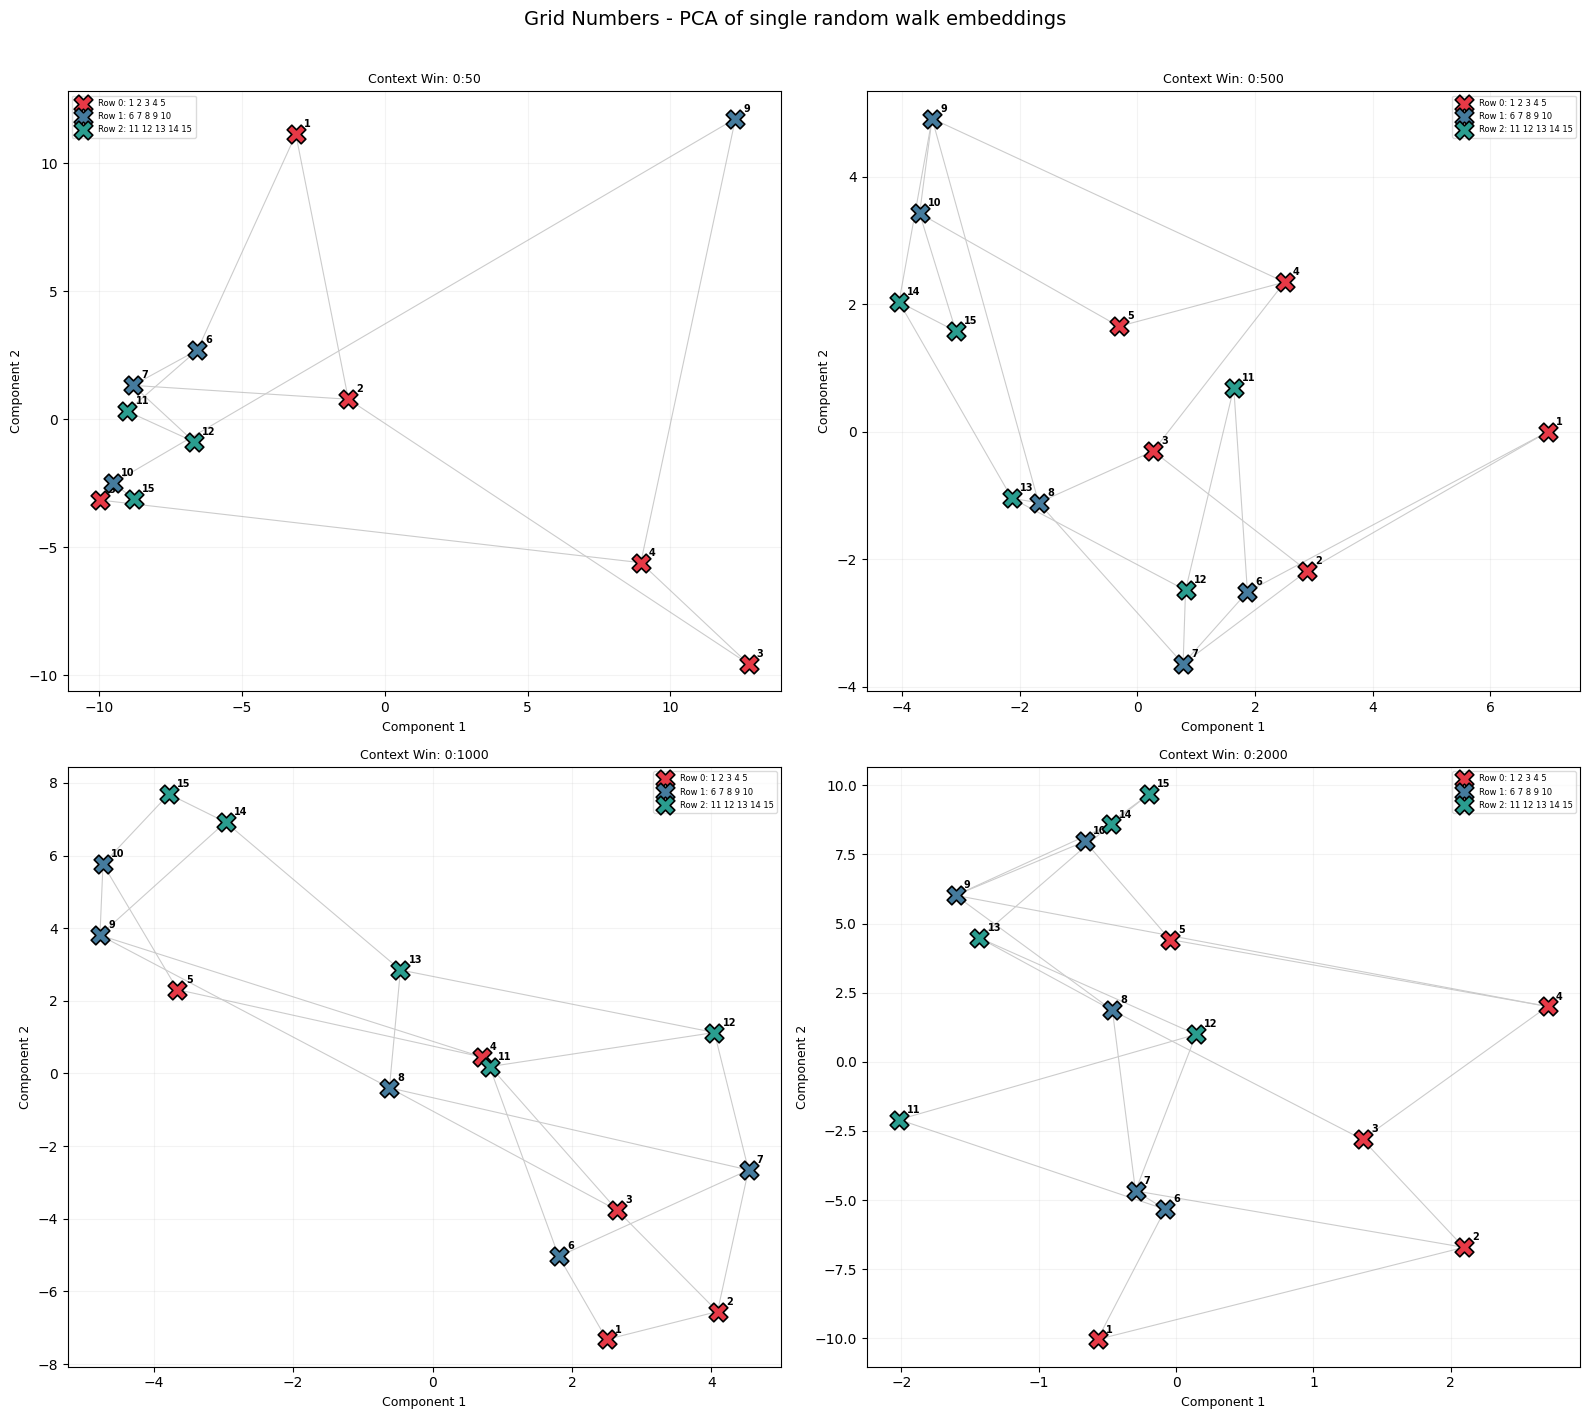

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,500, 1000, 2000]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_grid_numbers_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=100, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=True)

fig.suptitle("Grid Numbers - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 3.2: Numbers Grid (shuffled)

In [7]:
EMB_DIR     = Path("../embeddings/numbers/shuffled_grid_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_grid_numbers/grid_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

### PCA 2D

  [] Warning: token '15' has only 2 occurrences in [0:50] (requested 100)
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '13' has only 2 occurrences in [0:50] (requested 100)
  [] Warning: token '12' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '14' has only 3 occurrences in [0:50] (requested 100)
  [] Warning: token '4' has only 2 occurrences in [0:50] (requested 100)
  [] Warning: token '5' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '6' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '7' has only 4 occurrences in [0:50] (requested 100)
  [] Warning: token '8' has only 3 occurrences in [0:50] (requested 100)
  [] Warning: token '9' has only 3 occurrences in [0:50] (requested 100)
  [] Warning: token '10' has only 2 occurrences in [0:50] (requested 100)
  [] Warning: token '15' has only 8 occurrences in [0:500] (requested 100)
  [] Warning: token '11' has only 9 occurre

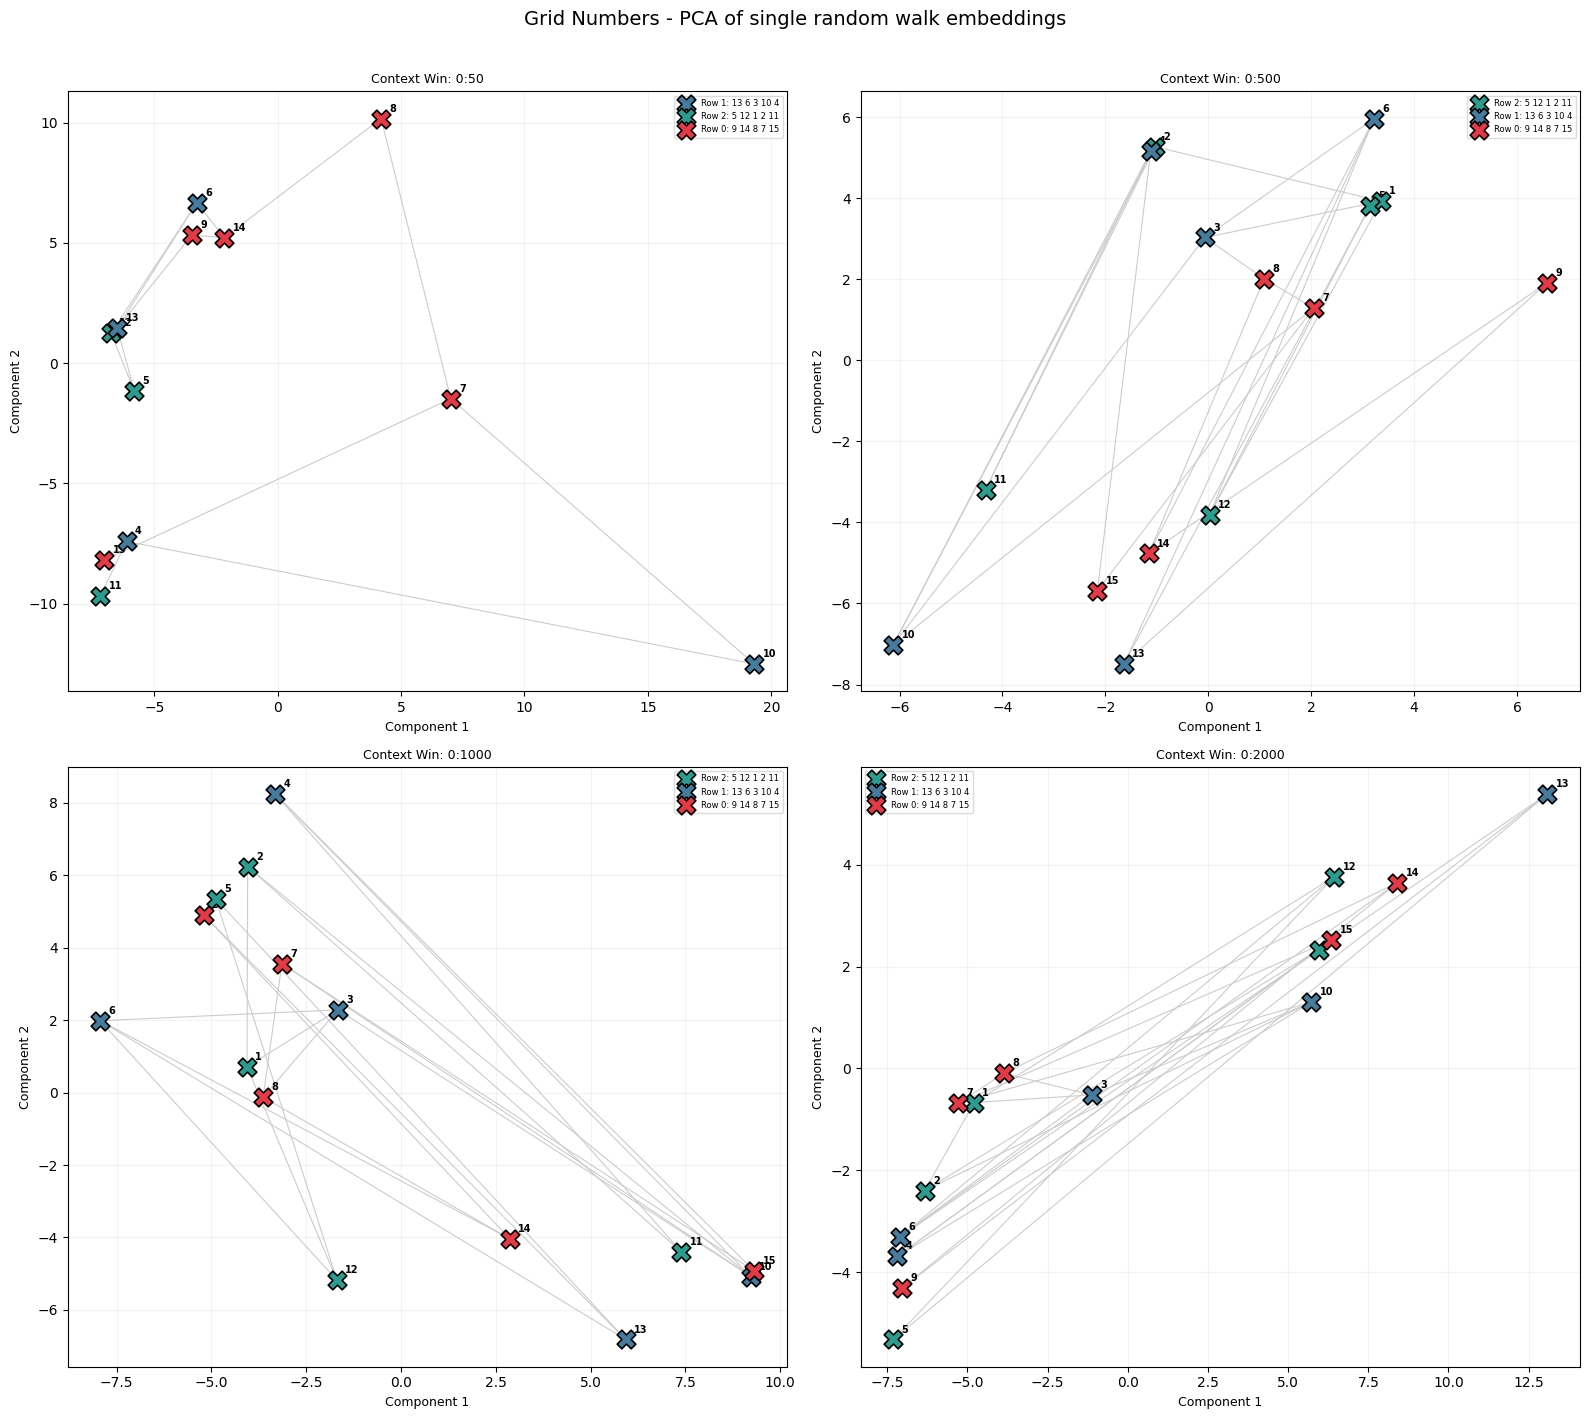

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,500, 1000, 2000]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_grid_numbers_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=100, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=True)

fig.suptitle("Grid Numbers - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 4: Numbers Tree - leaves only (ordered)

In [2]:
EMB_DIR     = Path("../embeddings/numbers/only_leaves_ordered_tree")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/only_leaves_ordered_tree/tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

KeyError: 'A'

### PCA 2D

AttributeError: 'Plotter' object has no attribute 'id_to_word'

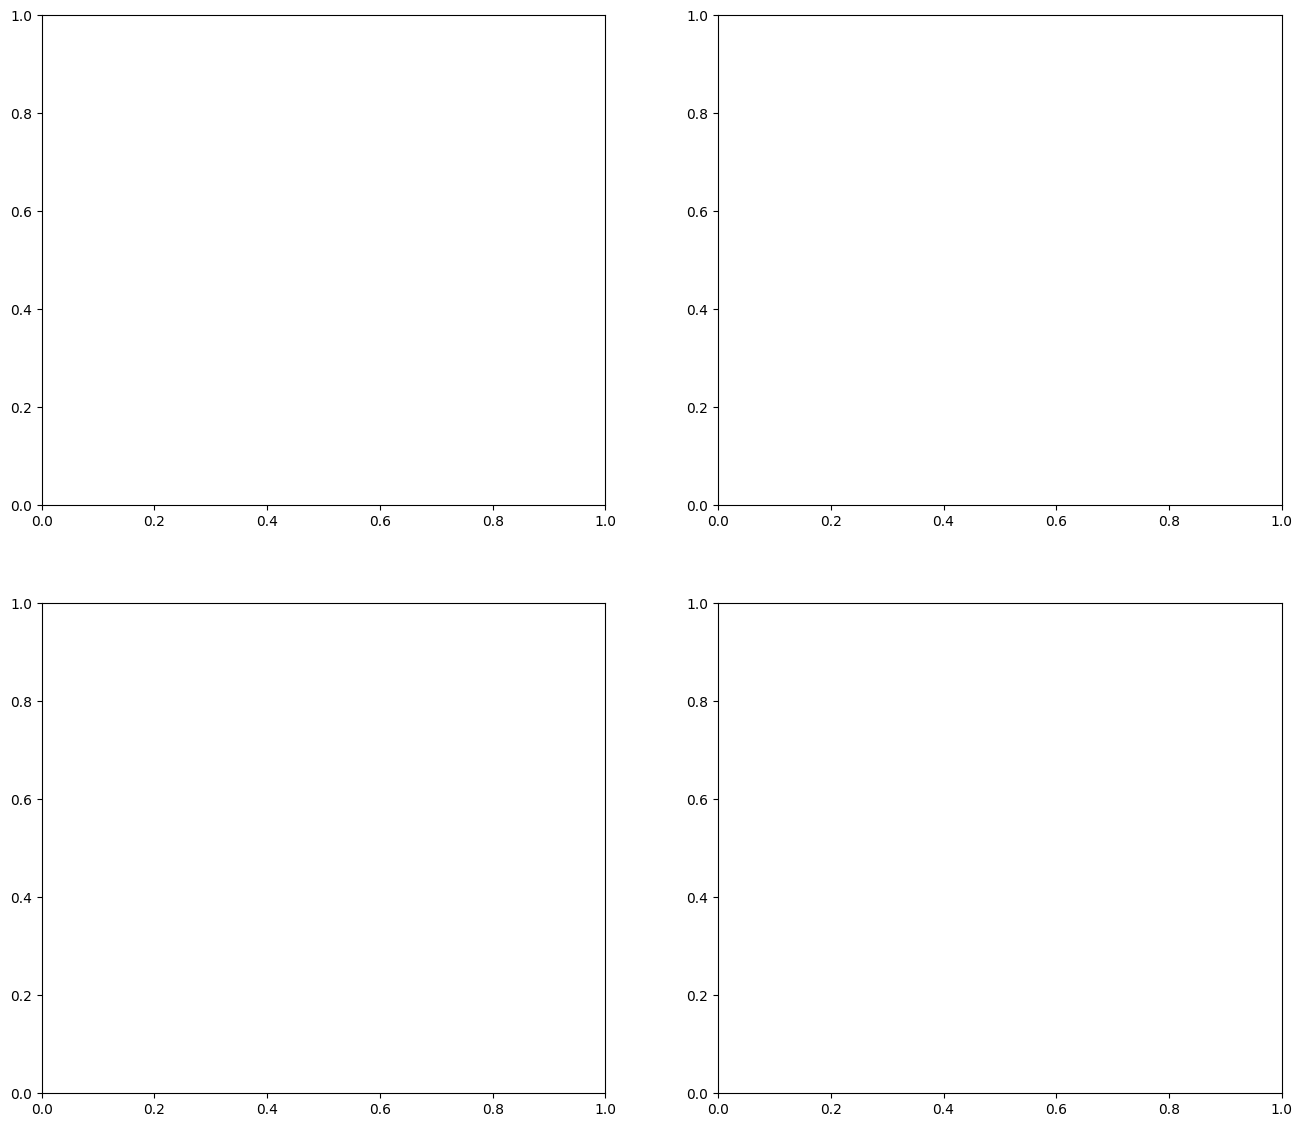

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,500, 1000, 2000]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=100, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=True)

fig.suptitle("Grid Numbers - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 4.2: Numbers Tree - leaves only (shuffled)

In [3]:
EMB_DIR     = Path("../embeddings/numbers/only_leaves_tree")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/only_leaves_tree/tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

### PCA 2D

  [] Warning: token '15' has only 9 occurrences in [0:50] (requested 100)
  [] Warning: token '13' has only 13 occurrences in [0:50] (requested 100)
  [] Warning: token '3' has only 2 occurrences in [0:50] (requested 100)
  [] Warning: token '5' has only 1 occurrences in [0:50] (requested 100)
  [] Warning: token '15' has only 26 occurrences in [0:500] (requested 100)
  [] Warning: token '11' has only 31 occurrences in [0:500] (requested 100)
  [] Warning: token '13' has only 34 occurrences in [0:500] (requested 100)
  [] Warning: token '1' has only 54 occurrences in [0:500] (requested 100)
  [] Warning: token '3' has only 31 occurrences in [0:500] (requested 100)
  [] Warning: token '5' has only 20 occurrences in [0:500] (requested 100)
  [] Warning: token '7' has only 29 occurrences in [0:500] (requested 100)
  [] Warning: token '9' has only 25 occurrences in [0:500] (requested 100)
  [] Warning: token '15' has only 66 occurrences in [0:1000] (requested 100)
  [] Warning: token '11' 

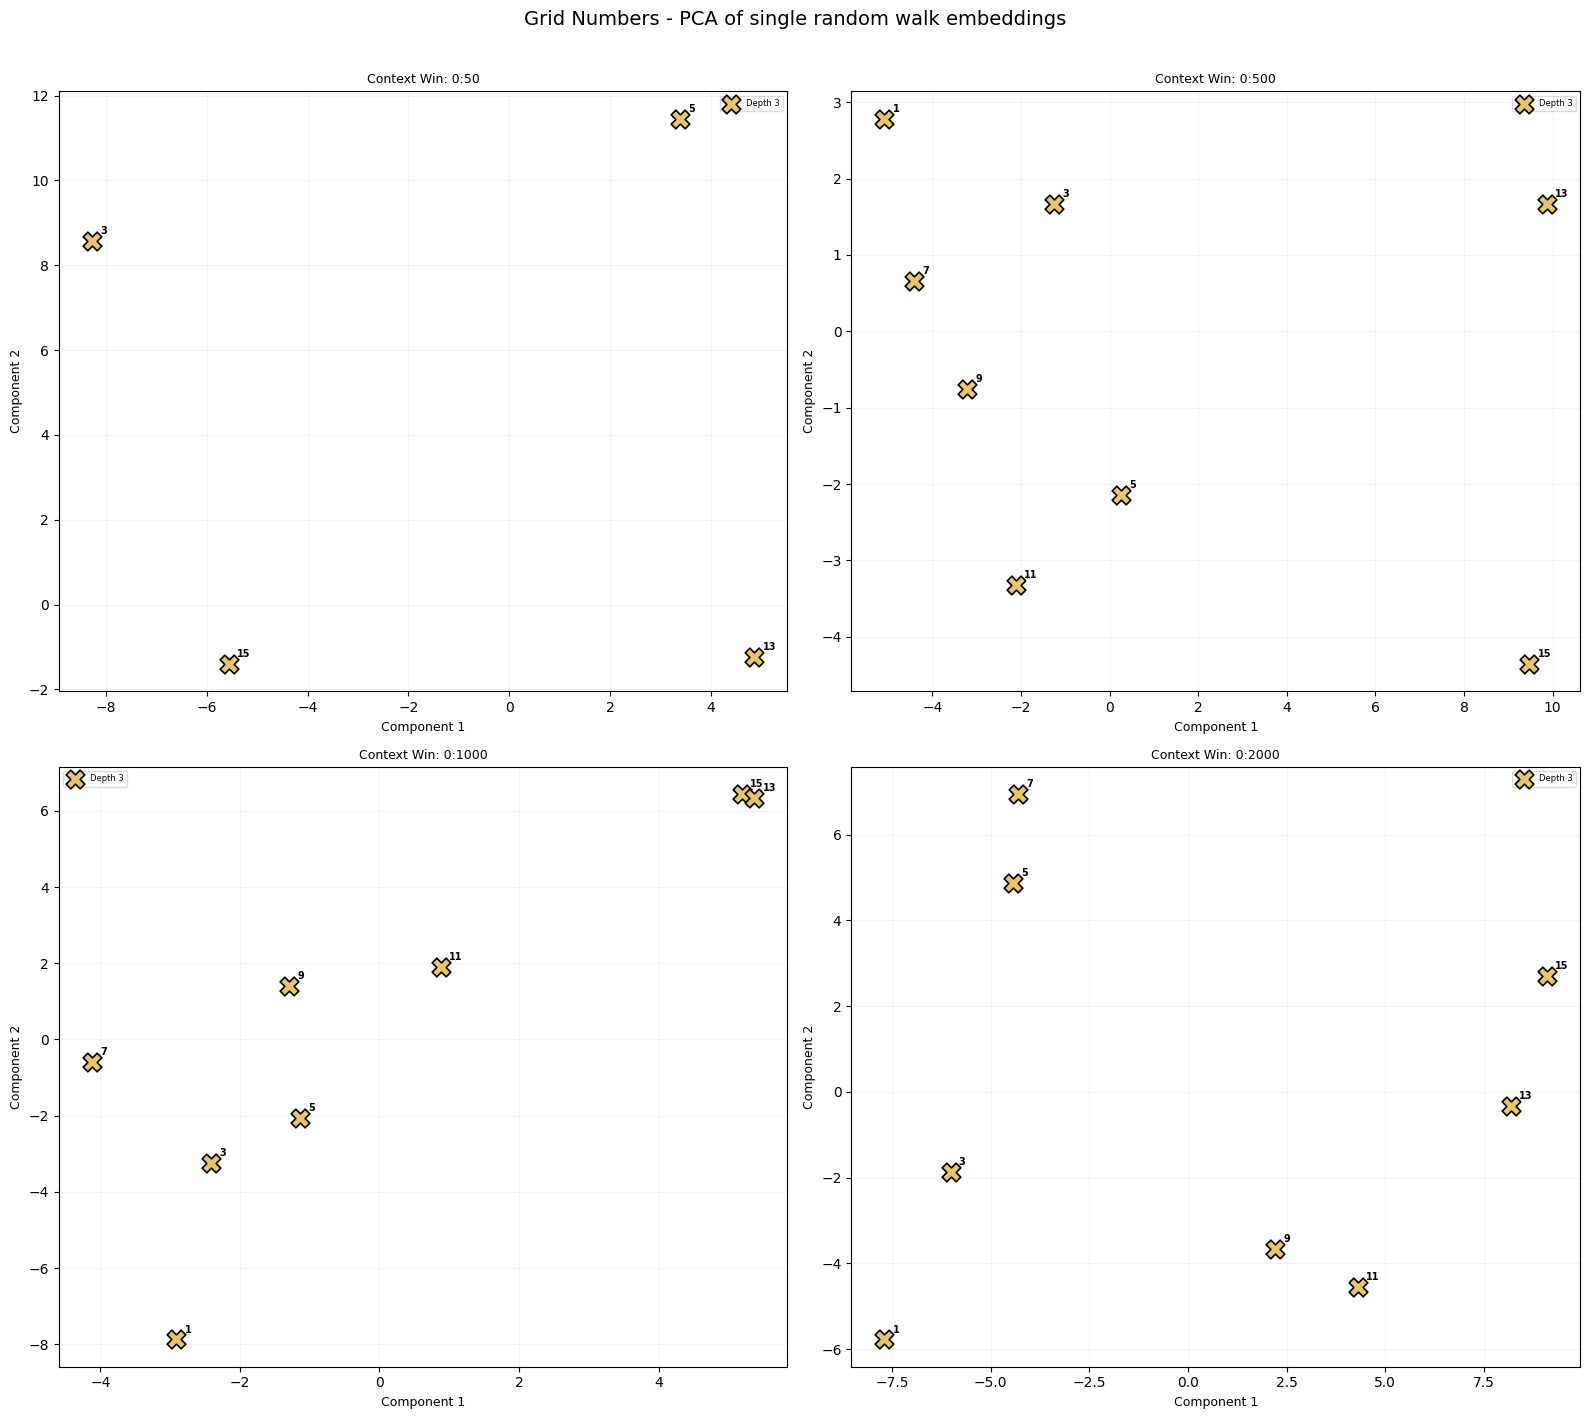

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,500, 1000, 2000]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=100, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=True)

fig.suptitle("Grid Numbers - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### dendrogram on centroids (cleaner plot)

Processing context length: 50
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '7' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
Processing context length: 500
Processing context length: 1000
Processing context length: 2000


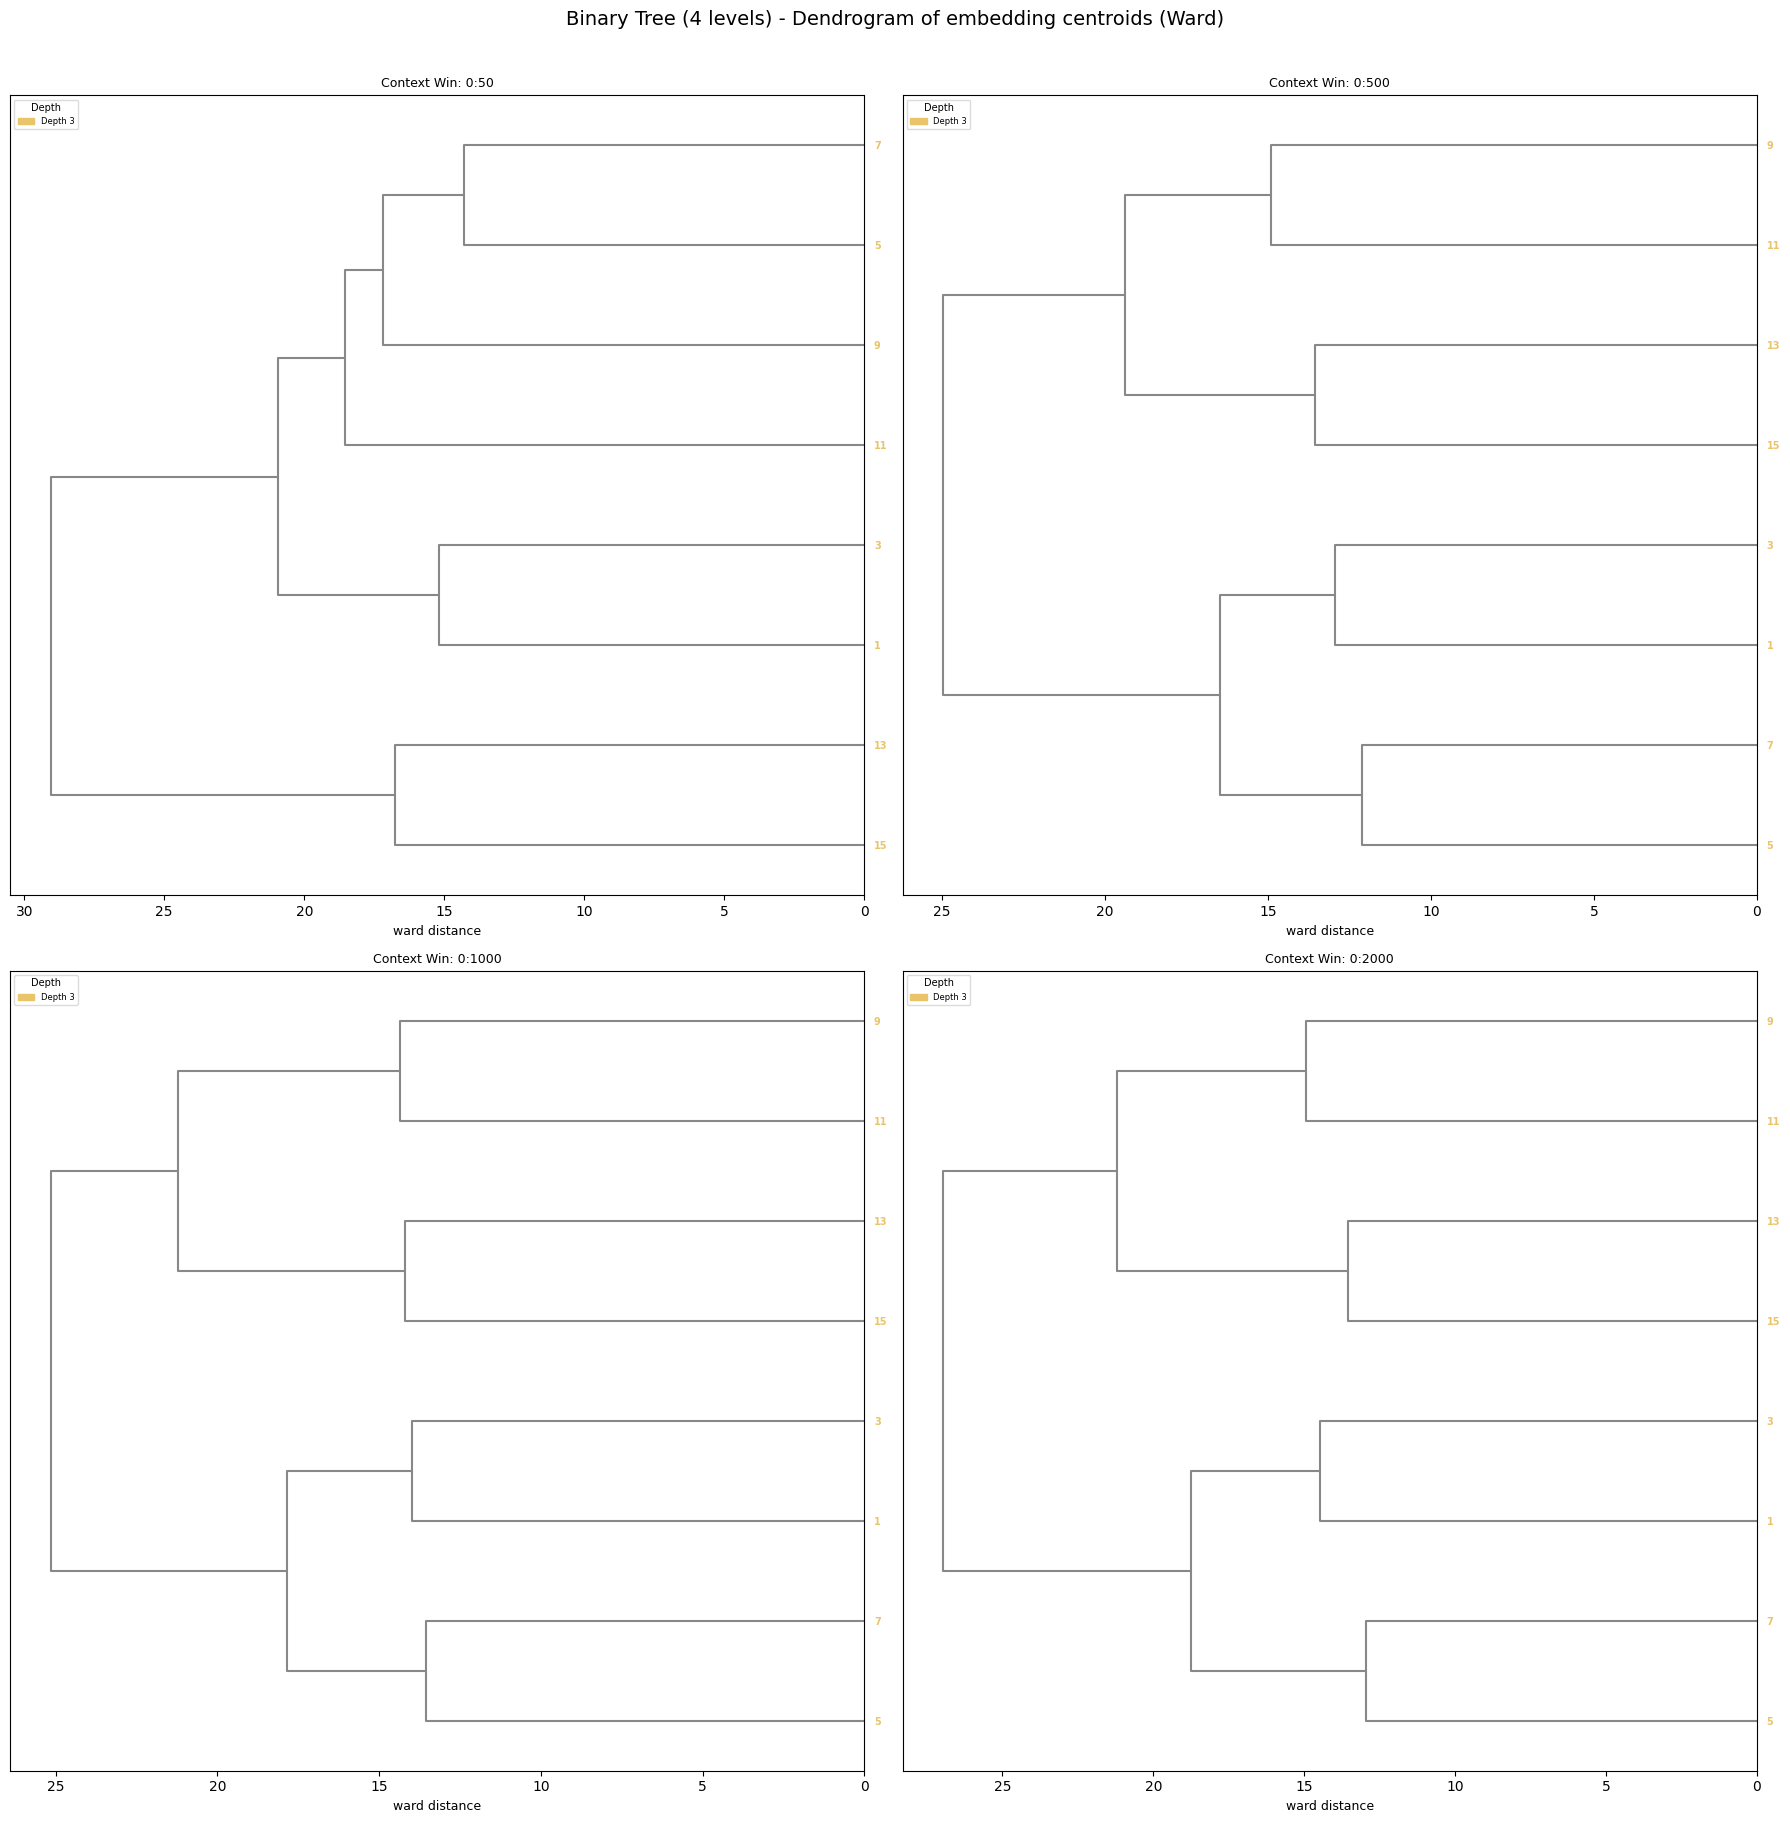

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Days Tree (3 levels)

In [ ]:
VOCAB_PATH  = Path("../data/days_tkid_map.txt")
STRUCT_PATH = Path("../data/one_random_walk/tree_days/bin_tree_structure.txt")
EMB_DIR     = Path("../embeddings/tree_days")

hp_tree_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

  [] Warning: token 'Saturday' has only 11 occurrences in [0:50] (requested 50)
  [] Warning: token 'Wednesday' has only 3 occurrences in [0:50] (requested 50)
  [] Warning: token 'Monday' has only 10 occurrences in [0:50] (requested 50)
  [] Warning: token 'Sunday' has only 1 occurrences in [0:50] (requested 50)
  [] Warning: token 'Tuesday' has only 23 occurrences in [0:50] (requested 50)
  [] Warning: token 'Saturday' has only 15 occurrences in [0:100] (requested 50)
  [] Warning: token 'Thursday' has only 1 occurrences in [0:100] (requested 50)
  [] Warning: token 'Wednesday' has only 13 occurrences in [0:100] (requested 50)
  [] Warning: token 'Friday' has only 1 occurrences in [0:100] (requested 50)
  [] Warning: token 'Monday' has only 19 occurrences in [0:100] (requested 50)
  [] Warning: token 'Sunday' has only 9 occurrences in [0:100] (requested 50)
  [] Warning: token 'Tuesday' has only 40 occurrences in [0:100] (requested 50)
  [] Warning: token 'Saturday' has only 22 occur

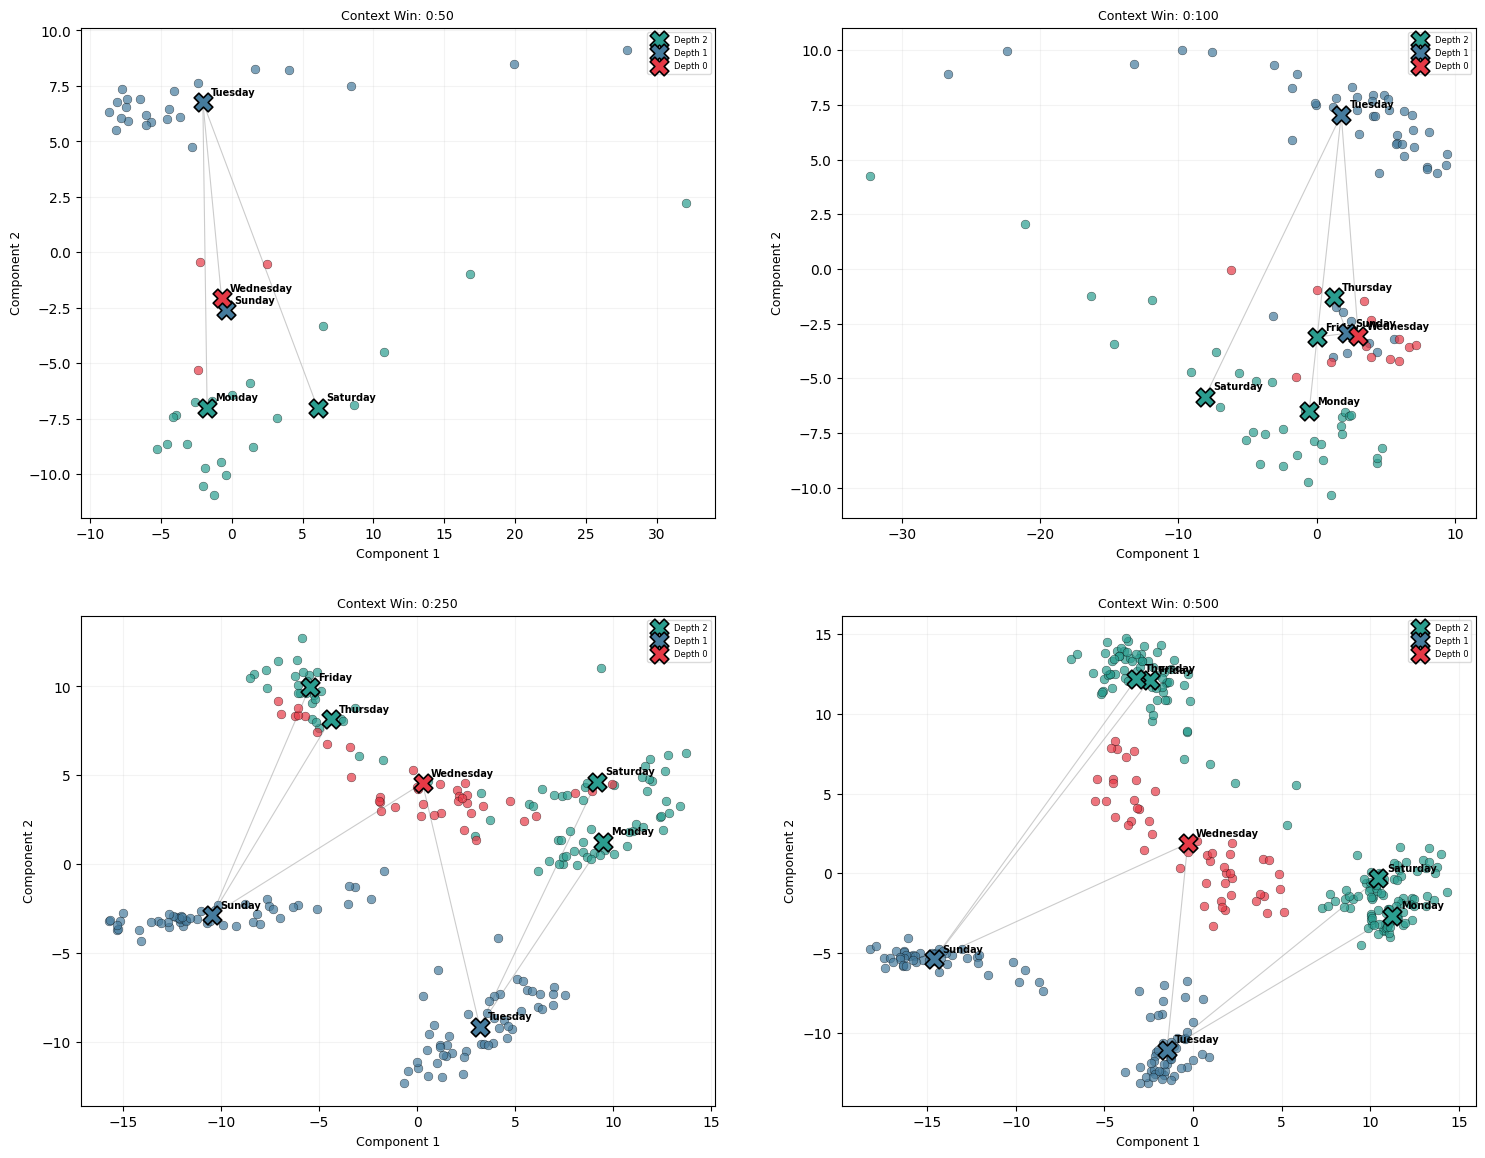

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 3000
CTX_LENS = [50,100,250, 500]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree_das.id_to_word, 
                                                     k=50, t_start=0, t_end=win_len)
    reducer = PCA(n_components=2, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_tree_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

  [] Warning: token 'Saturday' has only 11 occurrences in [0:50] (requested 50)
  [] Warning: token 'Wednesday' has only 3 occurrences in [0:50] (requested 50)
  [] Warning: token 'Monday' has only 10 occurrences in [0:50] (requested 50)
  [] Warning: token 'Sunday' has only 1 occurrences in [0:50] (requested 50)
  [] Warning: token 'Tuesday' has only 23 occurrences in [0:50] (requested 50)
  [] Warning: token 'Saturday' has only 15 occurrences in [0:100] (requested 50)
  [] Warning: token 'Thursday' has only 1 occurrences in [0:100] (requested 50)
  [] Warning: token 'Wednesday' has only 13 occurrences in [0:100] (requested 50)
  [] Warning: token 'Friday' has only 1 occurrences in [0:100] (requested 50)
  [] Warning: token 'Monday' has only 19 occurrences in [0:100] (requested 50)
  [] Warning: token 'Sunday' has only 9 occurrences in [0:100] (requested 50)
  [] Warning: token 'Tuesday' has only 40 occurrences in [0:100] (requested 50)
  [] Warning: token 'Saturday' has only 22 occur

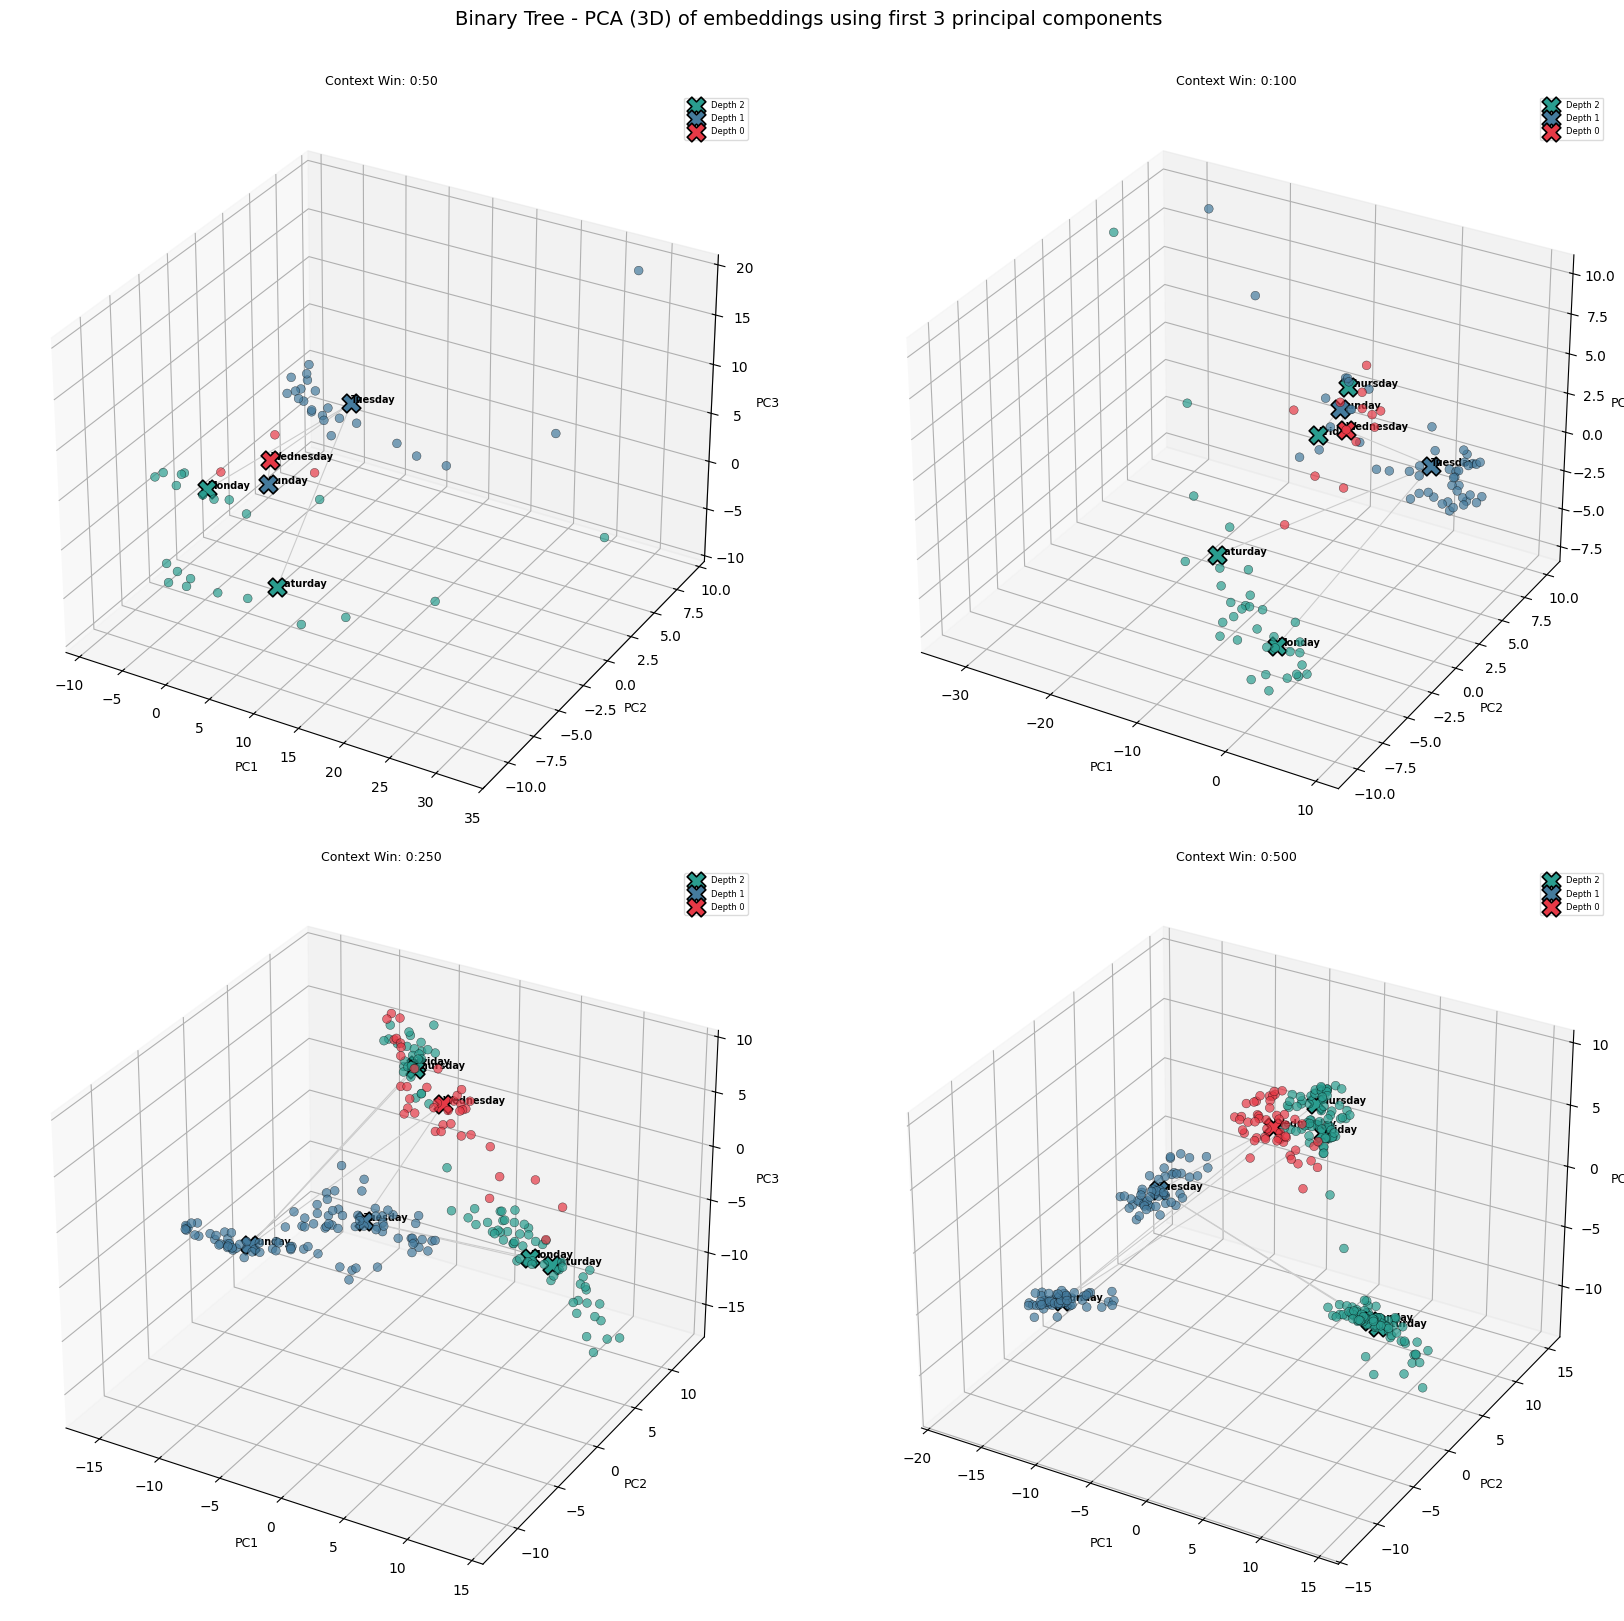

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 16))


for i, win_len in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')

    pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(
        ids_np,
        emb_np,
        hp_tree_das.id_to_word,
        k=50,
        t_start=0,
        t_end=win_len,
    )

    reducer = PCA(n_components=3, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)

    hp_tree_das.plot_reduced_emb(
        ax,
        pca_result,
        filtered_ids,
        title=f"Context Win: 0:{win_len}",
        only_centroid=False,   # or True if you want centroid-only like your UMAP example
    )

    # Optional: label axes
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

fig.suptitle(
    "Binary Tree - PCA (3D) of embeddings using first 3 principal components",
    fontsize=14,
    y=1.01,
)
fig.tight_layout()
plt.show()

Processing context length: 3000, window=50
  after layer filter: n=1012
  [] Warning: token 'Thursday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 6 occurrences in [0:50] (requested 10)
Processing context length: 3000, window=100
  after layer filter: n=1012
Processing context length: 3000, window=250
  after layer filter: n=1012
Processing context length: 3000, window=500
  after layer filter: n=1012


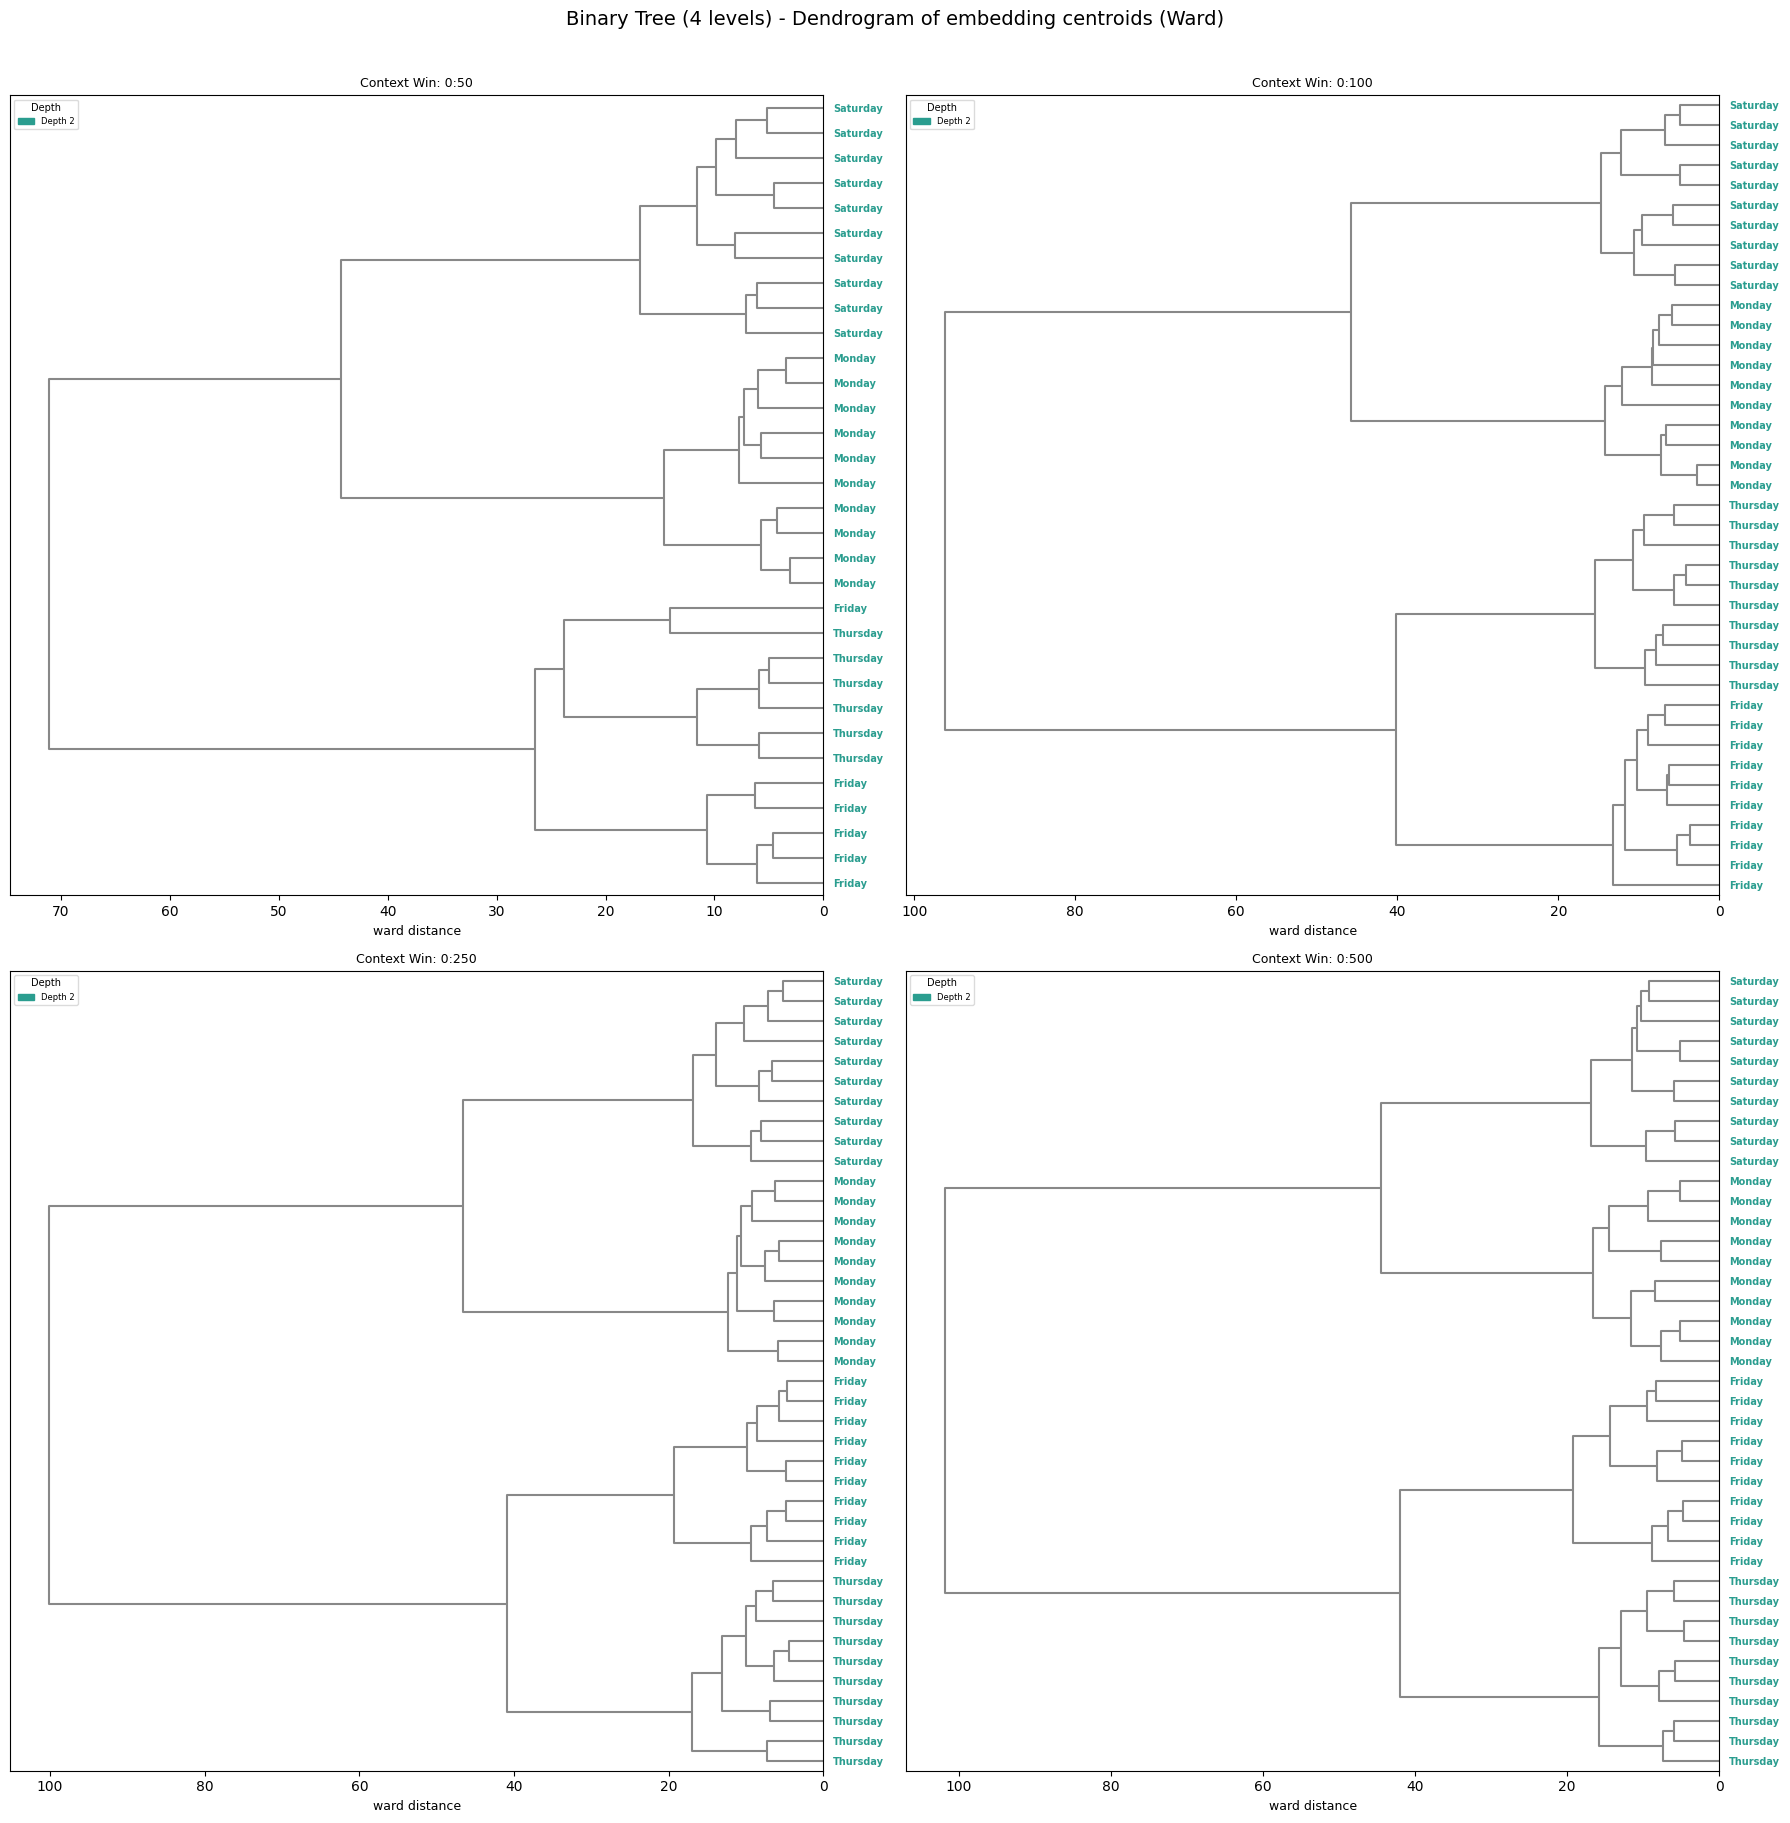

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 2

toks_layer_l = [toks for toks, depth in hp_tree_das.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree_das.word_to_tid[tok] for tok in toks_layer_l]

for ax, win_len in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {ctx}, window={win_len}")
    pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    # Keep only tokens from the selected layer
    mask_layer_l = np.isin(ids_np, ids_layer_l)
    ids_np_l = ids_np[mask_layer_l]
    emb_np_l = emb_np[mask_layer_l]

    print(f"  after layer filter: n={len(ids_np_l)}")

    filtered_ids, filtered_embs = _window_and_filter(
        ids_np_l,
        emb_np_l,
        hp_tree_das.id_to_word,
        k=10,
        t_end=win_len
    )

    hp_tree_das.plot_dendrogram_on_points(
        ax,
        filtered_ids,
        filtered_embs,
        title=f"Context Win: 0:{win_len}",
        method="ward",
        max_leaves=100
    )

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## centroids dendrogram

Processing context length: 3000, window=50
  after layer filter: n=1012
  [] Warning: token 'Thursday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 6 occurrences in [0:50] (requested 10)
Processing context length: 3000, window=100
  after layer filter: n=1012
Processing context length: 3000, window=250
  after layer filter: n=1012
Processing context length: 3000, window=500
  after layer filter: n=1012


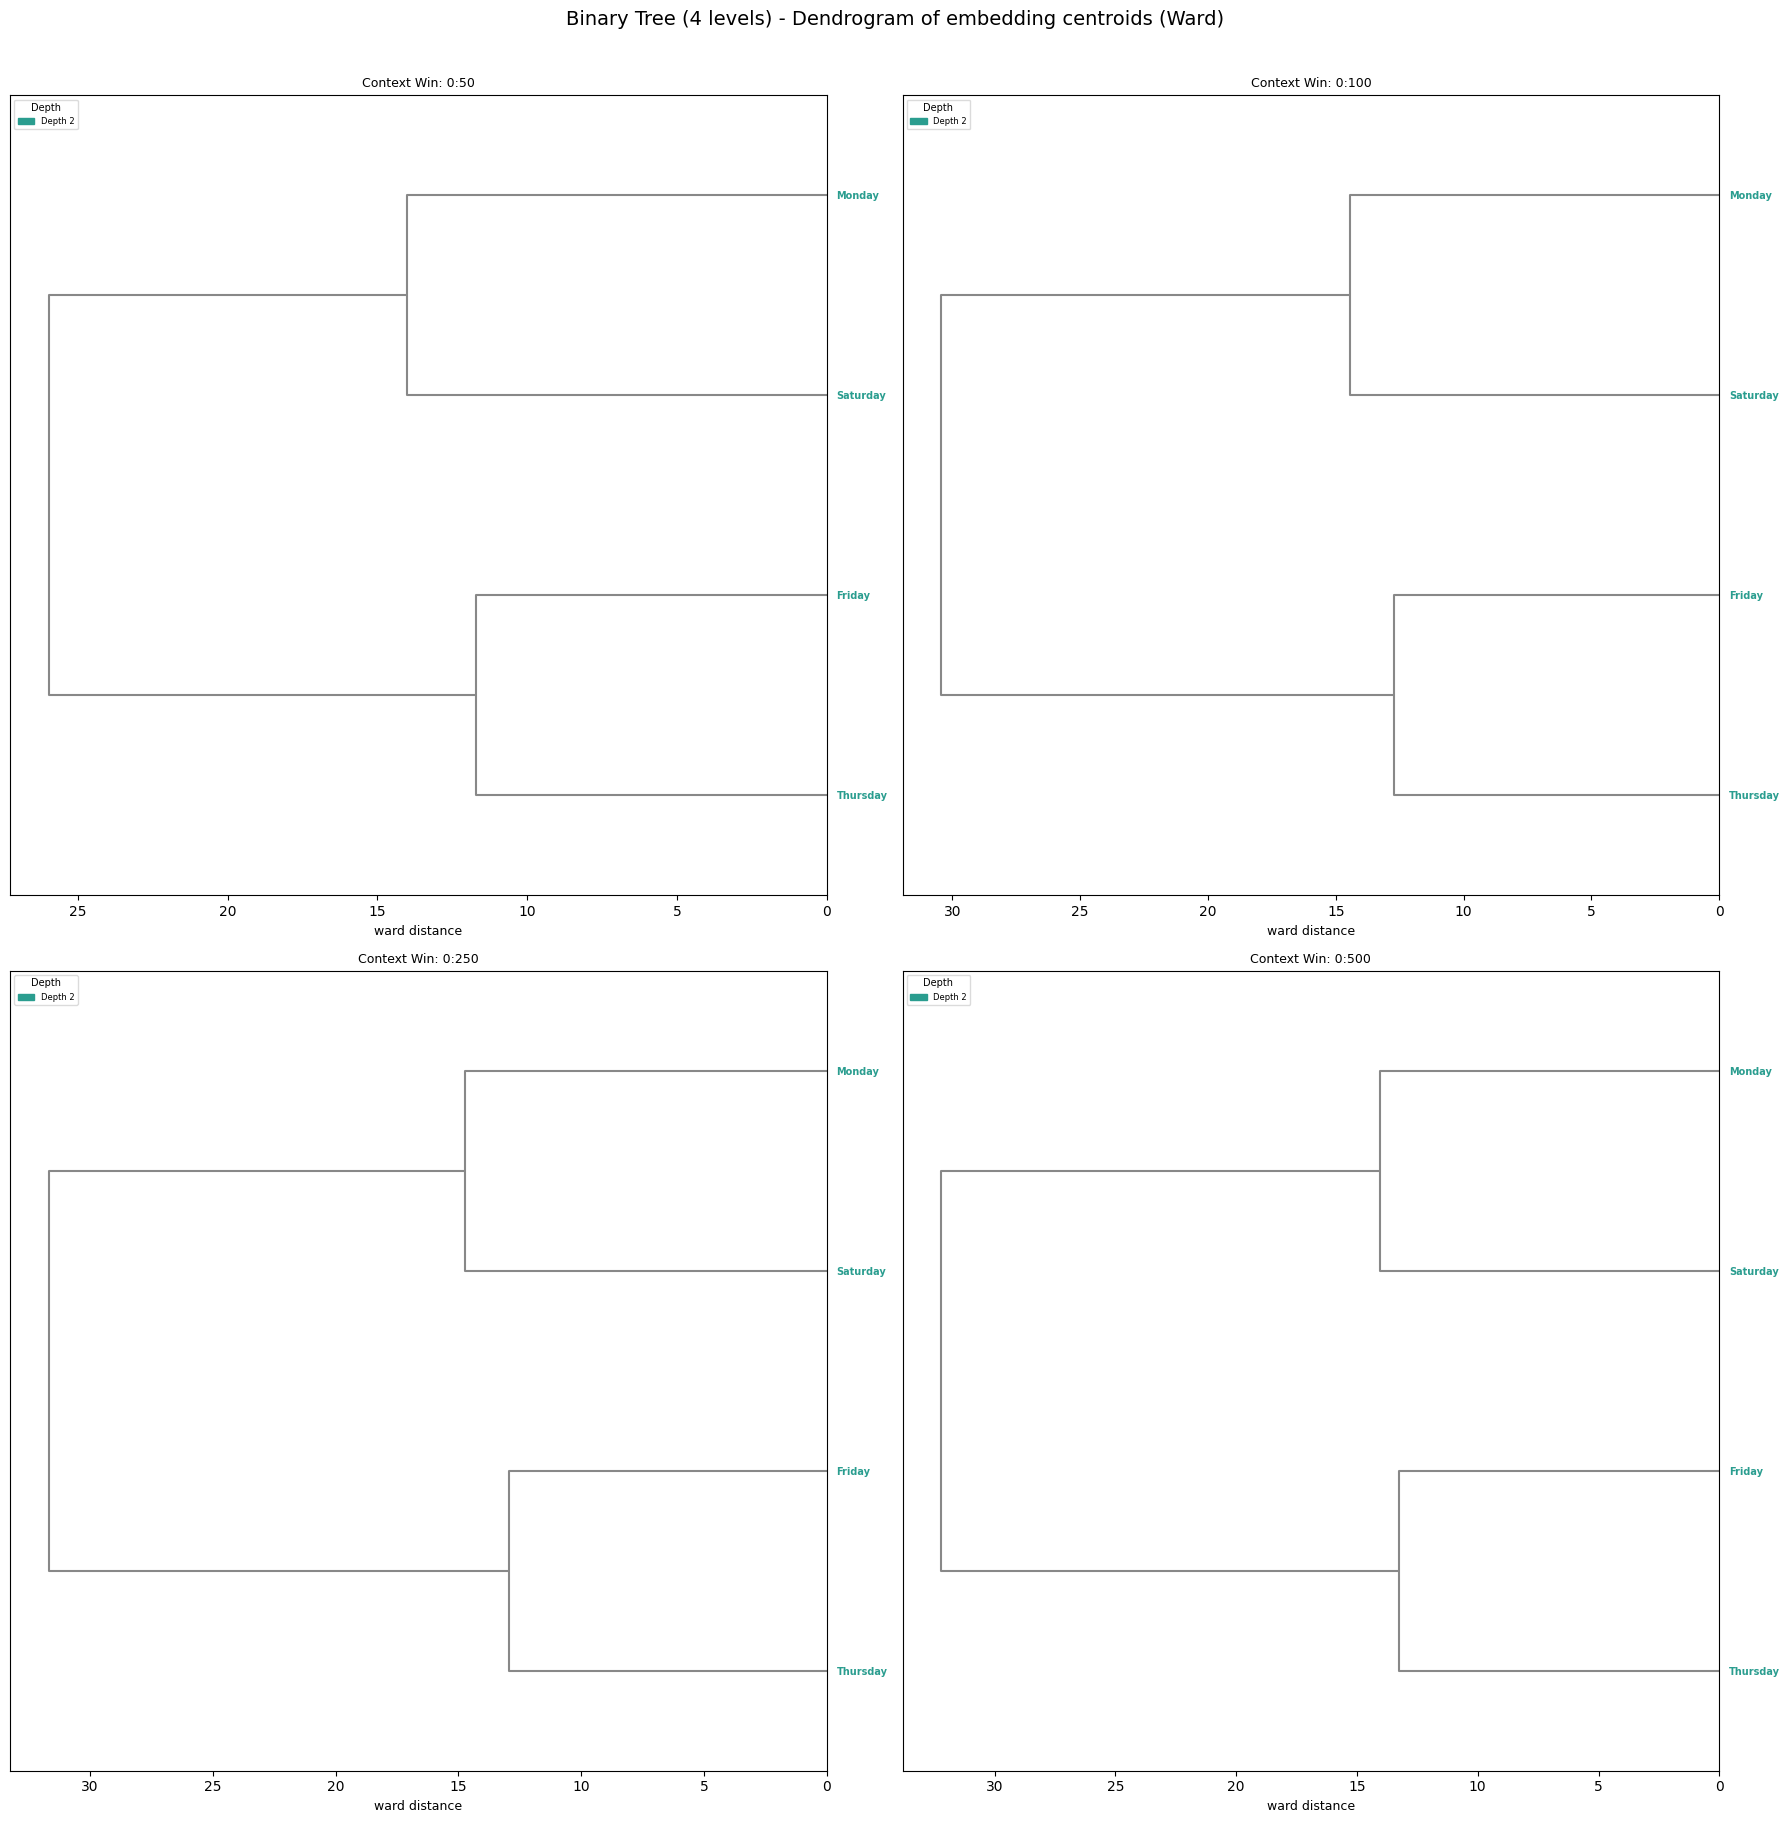

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 2

toks_layer_l = [toks for toks, depth in hp_tree_das.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree_das.word_to_tid[tok] for tok in toks_layer_l]

for ax, win_len in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {ctx}, window={win_len}")
    pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    # Keep only tokens from the selected layer
    mask_layer_l = np.isin(ids_np, ids_layer_l)
    ids_np_l = ids_np[mask_layer_l]
    emb_np_l = emb_np[mask_layer_l]

    print(f"  after layer filter: n={len(ids_np_l)}")

    filtered_ids, filtered_embs = _window_and_filter(
        ids_np_l,
        emb_np_l,
        hp_tree_das.id_to_word,
        k=10,
        t_end=win_len
    )

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree_das.plot_dendrogram_on_points(
        ax,
        centroids_id,
        centroids_emb,
        title=f"Context Win: 0:{win_len}",
        method="ward",
        max_leaves=100
    )

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()